In [1]:
import glob
from collections import defaultdict
from multiprocessing import Pool

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm
from Bio import SeqIO
from scipy.spatial.distance import cdist
from pymutspec.annotation.spectra import get_cossim, collapse_sbs192
from pymutspec.annotation import CodonAnnotation, rev_comp
from pymutspec.constants import possible_sbs192, possible_sbs12, possible_codons
from pymutspec.draw import plot_mutspec192, plot_mutspec12
from pymutspec.annotation import calculate_mutspec

import warnings
warnings.filterwarnings("ignore")

coda = CodonAnnotation(gencode=2)

## Derive species-specific spectra of mtDNA genes

### Calculate and save Expected mut counts for mtDNA genes

(with conservative sites)

In [2]:
# load raw alignments for each gene-species
paths_msa = glob.glob('/home/zengjl/data_local/nemu/output/*/*/1_*/msa_filtered.fasta') 
len(paths_msa)

521

In [3]:
#helper functions for parallel data processing 


def collect_exp_freqs_parallel(seq: str):
    exp12, exp192 = coda.collect_exp_mut_freqs(seq, labels=['syn'])
    return exp12['syn'], exp192['syn']


def collect_exp_parallel(seq: str):
    x = coda.collect_exp_muts(seq, labels=['syn'])
    x['Cxt'] = x['Mut'].apply(lambda x: x[0] + x[2] + x[-1])
    x = x[['Pos', 'Cxt']].drop_duplicates()
    cxt_freqs = x['Cxt'].value_counts().to_dict()
    return cxt_freqs

#计算输入序列中有效碱基（ACGT）的占比，返回一个介于0和1之间的值，表示有效碱基占总长度的比例
def calc_acgt_share(seq: str):
    """get share of sites that are not gaps (-) and Ns"""
    n = len(seq)
    acgt = seq.count("A") + seq.count("C") + seq.count("G") + seq.count("T")
    return acgt / n

In [4]:
# test parallel func
msa = [str(r.seq) for r in list(SeqIO.parse(paths_msa[10], 'fasta')) if r.id != 'OUTGRP']
collect_exp_freqs_parallel(msa[0])


p = Pool(64)
_ = p.map(collect_exp_freqs_parallel, msa)

In [5]:
# collect synonymous expected mutations counts (that will be used for spectra adjusting/normalization)
data = []
list_of_species = list()

i = 0
for path_fasta in tqdm.tqdm(paths_msa):
    i += 1
    p_elements = path_fasta.split('/')
    
    gene_species = p_elements[7]
    gene, species = gene_species.split('__')
    list_of_species.append(gene_species)

    msa = [str(r.seq) for r in list(SeqIO.parse(path_fasta, 'fasta')) if r.id != 'OUTGRP']

    # filter out partial seqs (< 80%)
    #calc_acgt_share()计算有效碱基占比
    #只保留 有效 ACGT 碱基占比 > 80% 的序列，直接剔除有效碱基 < 80% 的低质量、不完整序列
    msa_flt = [x for x in msa if calc_acgt_share(x) > 0.8]
    
    # collect descriptive features
    # 含义：统计【过滤后剩余的有效序列总数】
    #len(msa_flt)：计算列表里的元素个数
    msa_flt_nseqs = len(msa_flt)    

    # 含义：获取【多序列比对后的总位点数（列数）】
    msa_flt_ncols = len(msa_flt[0])

    # 含义：计算【所有有效序列的平均有效碱基占比】
    acgt_share_mean = np.mean([calc_acgt_share(x) for x in msa_flt])

    # get expected mutations counts for all sequences in aligment in parallel manner
    raw = p.map(collect_exp_freqs_parallel, msa_flt)

    # split 12-component counts and 192-component ones
    raw_exp12  = [x[0] for x in raw]
    raw_exp192 = [x[1] for x in raw]

    nseqs = len(msa_flt)
    
    # put all data about one spectrum into dict
    mean_exp = defaultdict(float)
    mean_exp['gene'] = gene
    mean_exp['species'] = species
    mean_exp['msa_nseqs'] = msa_flt_nseqs
    mean_exp['msa_ncols'] = msa_flt_ncols
    mean_exp['acgt_share'] = acgt_share_mean
    for sbs in possible_sbs12:
        for rex in raw_exp12:
            mean_exp[sbs] += rex.get(sbs, 0.) / nseqs
    for sbs in possible_sbs192:
        for rex in raw_exp192:
            mean_exp[sbs] += rex.get(sbs, 0.) / nseqs
        
    data.append(mean_exp)

    # if i >= 100:
    #     break

exp_raw_df = pd.DataFrame(data)
exp_raw_df.to_csv('./new_dataset/exp_num_raw.csv', index=False)

100%|██████████| 521/521 [00:06<00:00, 82.16it/s] 


In [6]:
exp_raw_df

,gene,species,msa_nseqs,msa_ncols,acgt_share,A>C,A>G,A>T,C>A,C>G,...,C[T>G]G,C[T>G]T,G[T>G]A,G[T>G]C,G[T>G]G,G[T>G]T,T[T>G]A,T[T>G]C,T[T>G]G,T[T>G]T
0,A8,Bostrychus_sinensis,7,165,1.000000,11.285714,24.000000,11.285714,8.285714,8.285714,...,0.000000,1.428571,0.000000,0.000000,0.000000,0.000000,0.714286,0.000000,0.285714,1.428571
1,A8,Gobiosoma_bosc,17,159,1.000000,13.176471,23.705882,13.176471,7.294118,7.294118,...,0.823529,0.294118,0.000000,0.000000,0.235294,0.000000,0.352941,0.000000,0.000000,0.000000
2,A8,Mogurnda_adspersa,14,123,0.998258,7.785714,13.642857,7.785714,8.928571,8.928571,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.214286,0.000000,0.785714,1.000000
3,A8,Chaenogobius_annularis,26,162,0.986467,8.153846,20.384615,8.153846,8.769231,8.769231,...,0.923077,0.961538,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.961538,0.000000
4,ND2,Luciogobius_ryukyuensis,14,945,1.000000,50.928571,109.285714,50.928571,59.071429,59.071429,...,6.071429,7.285714,0.000000,0.000000,0.000000,2.000000,9.071429,9.000000,11.000000,5.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
516,ND4,Milyeringa_veritas,11,684,1.000000,45.818182,75.818182,45.818182,53.818182,53.818182,...,2.000000,2.000000,0.090909,0.000000,0.000000,0.000000,5.727273,3.545455,2.000000,3.000000
517,ND4,Chaenogobius_annularis,114,1380,0.996625,78.429825,148.368421,78.429825,62.877193,62.877193,...,8.333333,11.938596,2.394737,1.394737,1.377193,1.385965,12.228070,9.254386,13.114035,10.035088
518,ND4,Luciogobius_ryukyuensis,17,1323,1.000000,84.411765,170.117647,84.411765,69.588235,69.588235,...,9.058824,13.176471,3.000000,1.000000,1.000000,1.000000,11.823529,9.000000,11.000000,5.941176
519,ND4,Lentipes_armatus,22,1380,1.000000,103.545455,164.090909,103.545455,91.590909,91.590909,...,9.409091,4.636364,1.363636,0.000000,0.590909,1.045455,6.045455,11.545455,13.000000,1.954545


In [7]:
# collect synonymous contexts freqs for QC
data_cxt = []

i = 0
for path_fasta in tqdm.tqdm(paths_msa):
    i += 1
    p_elements = path_fasta.split('/')
    
    gene_species = p_elements[7]
    gene, species = gene_species.split('__')

    msa = [str(r.seq) for r in list(SeqIO.parse(path_fasta, 'fasta')) if r.id != 'OUTGRP']

    # filter out partial seqs (< 80%)
    msa_flt = [x for x in msa if calc_acgt_share(x) > 0.8]
    
    raw_cxt_freqs = p.map(collect_exp_parallel, msa_flt)

    nseqs = len(msa_flt)
    mean_exp = defaultdict(float)
    mean_exp['gene'] = gene
    mean_exp['species'] = species

    for cxt in possible_codons:
        for rex in raw_cxt_freqs:
            mean_exp[cxt] += rex.get(cxt, 0.) / nseqs
    
    data_cxt.append(mean_exp)
    # if i == 10:
    #     break

cxt_df = pd.DataFrame(data_cxt)
cxt_df.to_csv('./new_dataset/exp_cxt_freqs.csv', index=False)
cxt_df

100%|██████████| 521/521 [00:08<00:00, 59.27it/s]


,gene,species,AAA,AAC,AAG,AAT,ACA,ACC,ACG,ACT,...,TCG,TCT,TGA,TGC,TGG,TGT,TTA,TTC,TTG,TTT
0,A8,Bostrychus_sinensis,2.000000,0.714286,3.000000,1.000000,0.000000,1.000000,0.000000,3.000000,...,0.714286,1.285714,0.000000,1.142857,0.714286,0.285714,0.714286,2.000000,0.571429,2.428571
1,A8,Gobiosoma_bosc,2.294118,1.000000,1.000000,1.000000,1.000000,2.058824,0.352941,2.941176,...,0.411765,1.117647,0.000000,0.882353,0.470588,0.352941,0.352941,0.411765,1.705882,2.764706
2,A8,Mogurnda_adspersa,0.928571,1.714286,1.000000,0.000000,1.000000,0.928571,0.857143,1.000000,...,0.000000,1.500000,0.000000,2.000000,0.000000,0.000000,1.214286,2.000000,1.785714,1.571429
3,A8,Chaenogobius_annularis,3.192308,1.500000,0.615385,1.269231,0.038462,1.000000,0.000000,0.000000,...,0.961538,2.000000,0.038462,1.000000,0.000000,0.000000,0.000000,2.807692,5.000000,1.000000
4,ND2,Luciogobius_ryukyuensis,3.714286,7.071429,5.357143,4.071429,4.000000,8.928571,1.000000,11.357143,...,1.000000,3.000000,4.071429,4.000000,0.071429,0.000000,17.071429,15.000000,19.928571,14.285714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
516,ND4,Milyeringa_veritas,3.000000,5.363636,2.000000,0.000000,3.909091,5.000000,3.000000,7.363636,...,2.000000,6.909091,3.272727,5.363636,3.000000,0.000000,12.363636,5.545455,4.363636,4.000000
517,ND4,Chaenogobius_annularis,8.657895,7.438596,4.315789,1.017544,6.754386,7.929825,0.622807,10.921053,...,0.026316,14.728070,9.684211,6.017544,9.429825,6.157895,23.368421,15.429825,23.570175,32.859649
518,ND4,Luciogobius_ryukyuensis,10.941176,9.000000,4.000000,2.000000,10.117647,10.000000,0.000000,14.000000,...,3.000000,14.823529,3.705882,1.352941,1.882353,1.294118,24.000000,13.000000,17.000000,27.764706
519,ND4,Lentipes_armatus,8.409091,8.181818,4.090909,0.000000,13.909091,10.954545,0.954545,8.454545,...,1.772727,18.590909,3.636364,7.590909,4.090909,0.090909,16.818182,15.500000,22.181818,8.000000


### Merge observed (reconstructed by NeMu-pipeline) mutations tables

In [8]:
# NeMu-pipeline generate many output files in several directories for each input
# So, we also need to aggregate the outputs

paths_observed = glob.glob('/home/zengjl/data_local/nemu/output/*/*/1_*/observed_mutations.tsv')
cols_useless = ['ProbaFull', 'Gene']
data_obs = []
#存放被跳过的异常文件，其tsv文件可能存在格式问题、缺失数据等异常情况，导致无法正常读取和处理
skipped_files = []

for p in tqdm.tqdm(paths_observed, 'Species-Gene'):
    gene, species = p.split('/')[7].split('__')
    try:
        spectrum = pd.read_csv(p, sep='\t')
          # 若只有表头没有数据行，也可以跳过
        if spectrum.empty:
            print(f"Warning: skipped empty dataframe in {p}")
            skipped_files.append(p)
            continue
        spectrum = spectrum.assign(species=species, gene=gene)\
            .drop(cols_useless, axis=1).rename(columns={'PosInGene': 'Site', 'Label': 'MutType'})
        data_obs.append(spectrum)
    except Exception as e:
        print(f"Error reading {p}: {e}")
        skipped_files.append(p)
        continue
if data_obs:
    obs_df = pd.concat(data_obs)
    obs_df.to_csv('/home/zengjl/WorkSpace/mtdna-192component-mutspec-chordata/1data_derivation/new_dataset/raw_obs_muts.csv', index=False)
else:
    print("No valid dataframes found, nothing was aggregated.")

if skipped_files:
    print(f"\nSkipped files due to error ({len(skipped_files)}):")
    for f in skipped_files:
        print(f)
obs_df = pd.concat(data_obs)
obs_df.to_csv(f'/home/zengjl/WorkSpace/mtdna-192component-mutspec-chordata/1data_derivation/new_dataset/raw_obs_muts.csv', index=False)

Species-Gene:  20%|█▉        | 99/500 [00:00<00:01, 278.42it/s]

Species-Gene:  36%|███▌      | 181/500 [00:00<00:01, 265.85it/s]

Error reading /home/zengjl/data_local/nemu/output/Cytb/Cytb__Knipowitschia_panizzae/1__MK619429.1__Knipowitschia_panizzae/observed_mutations.tsv: No columns to parse from file


Species-Gene:  58%|█████▊    | 292/500 [00:01<00:00, 272.20it/s]

Error reading /home/zengjl/data_local/nemu/output/CO1/CO1__Zosterisessor_ophiocephalus/1__FJ526798.1__Zosterisessor_ophiocephalus/observed_mutations.tsv: No columns to parse from file


Species-Gene:  78%|███████▊  | 391/500 [00:01<00:00, 314.27it/s]

Error reading /home/zengjl/data_local/nemu/output/CO1/CO1__Nemateleotris_magnifica/1__OP035110.1__Nemateleotris_magnifica/observed_mutations.tsv: No columns to parse from file
Error reading /home/zengjl/data_local/nemu/output/CO1/CO1__Sicyopterus_japonicus/1__MK496945.1__Sicyopterus_japonicus/observed_mutations.tsv: No columns to parse from file


Species-Gene: 100%|██████████| 500/500 [00:01<00:00, 286.94it/s]



Skipped files due to error (4):
/home/zengjl/data_local/nemu/output/Cytb/Cytb__Knipowitschia_panizzae/1__MK619429.1__Knipowitschia_panizzae/observed_mutations.tsv
/home/zengjl/data_local/nemu/output/CO1/CO1__Zosterisessor_ophiocephalus/1__FJ526798.1__Zosterisessor_ophiocephalus/observed_mutations.tsv
/home/zengjl/data_local/nemu/output/CO1/CO1__Nemateleotris_magnifica/1__OP035110.1__Nemateleotris_magnifica/observed_mutations.tsv
/home/zengjl/data_local/nemu/output/CO1/CO1__Sicyopterus_japonicus/1__MK496945.1__Sicyopterus_japonicus/observed_mutations.tsv


# all mutations for all processed genes of all species
# Label=0 means NON-SYN mutation
# Label=1 means SYN mutation
# Label=2 means SYN mutation at fourfold site

obs_df

## Analysis and filtration of exp

In [10]:
# exp_raw_df = pd.read_csv('../data/new_dataset/exp_num_raw.csv')
exp_raw_df

,gene,species,msa_nseqs,msa_ncols,acgt_share,A>C,A>G,A>T,C>A,C>G,...,C[T>G]G,C[T>G]T,G[T>G]A,G[T>G]C,G[T>G]G,G[T>G]T,T[T>G]A,T[T>G]C,T[T>G]G,T[T>G]T
0,A8,Bostrychus_sinensis,7,165,1.000000,11.285714,24.000000,11.285714,8.285714,8.285714,...,0.000000,1.428571,0.000000,0.000000,0.000000,0.000000,0.714286,0.000000,0.285714,1.428571
1,A8,Gobiosoma_bosc,17,159,1.000000,13.176471,23.705882,13.176471,7.294118,7.294118,...,0.823529,0.294118,0.000000,0.000000,0.235294,0.000000,0.352941,0.000000,0.000000,0.000000
2,A8,Mogurnda_adspersa,14,123,0.998258,7.785714,13.642857,7.785714,8.928571,8.928571,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.214286,0.000000,0.785714,1.000000
3,A8,Chaenogobius_annularis,26,162,0.986467,8.153846,20.384615,8.153846,8.769231,8.769231,...,0.923077,0.961538,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.961538,0.000000
4,ND2,Luciogobius_ryukyuensis,14,945,1.000000,50.928571,109.285714,50.928571,59.071429,59.071429,...,6.071429,7.285714,0.000000,0.000000,0.000000,2.000000,9.071429,9.000000,11.000000,5.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
516,ND4,Milyeringa_veritas,11,684,1.000000,45.818182,75.818182,45.818182,53.818182,53.818182,...,2.000000,2.000000,0.090909,0.000000,0.000000,0.000000,5.727273,3.545455,2.000000,3.000000
517,ND4,Chaenogobius_annularis,114,1380,0.996625,78.429825,148.368421,78.429825,62.877193,62.877193,...,8.333333,11.938596,2.394737,1.394737,1.377193,1.385965,12.228070,9.254386,13.114035,10.035088
518,ND4,Luciogobius_ryukyuensis,17,1323,1.000000,84.411765,170.117647,84.411765,69.588235,69.588235,...,9.058824,13.176471,3.000000,1.000000,1.000000,1.000000,11.823529,9.000000,11.000000,5.941176
519,ND4,Lentipes_armatus,22,1380,1.000000,103.545455,164.090909,103.545455,91.590909,91.590909,...,9.409091,4.636364,1.363636,0.000000,0.590909,1.045455,6.045455,11.545455,13.000000,1.954545


In [10]:
# acgt_share is normal (>0.95), i.e. we have low number of gaps and Ns
exp_raw_df.groupby('gene').acgt_share.describe()

,count,mean,std,min,25%,50%,75%,max
gene,,,,,,,,
A6,17.0,0.999039,0.002931,0.988567,1.000000,1.000000,1.000000,1.0
A8,4.0,0.996181,0.006528,0.986467,0.995310,0.999129,1.000000,1.0
CO1,261.0,0.984074,0.017942,0.904255,0.976177,0.988968,0.997525,1.0
CO2,8.0,0.999472,0.001493,0.995778,1.000000,1.000000,1.000000,1.0
CO3,9.0,0.999284,0.002149,0.993553,1.000000,1.000000,1.000000,1.0
Cytb,128.0,0.993813,0.013863,0.925094,0.995390,0.999852,1.000000,1.0
ND1,14.0,0.998068,0.005687,0.978802,1.000000,1.000000,1.000000,1.0
ND2,24.0,0.990543,0.013469,0.949677,0.986800,0.997400,1.000000,1.0
ND3,8.0,0.998501,0.004241,0.988004,1.000000,1.000000,1.000000,1.0


In [11]:
# msa_nseqs (number of seqs in alignment) is ok (>=7 in general; >=13 in average)
exp_raw_df.groupby('gene').msa_nseqs.describe()

,count,mean,std,min,25%,50%,75%,max
gene,,,,,,,,
A6,17.0,26.117647,19.839614,7.0,13.00,18.0,35.00,71.0
A8,4.0,16.000000,7.874008,7.0,12.25,15.5,19.25,26.0
CO1,261.0,14.122605,14.476782,3.0,7.00,10.0,15.00,140.0
CO2,8.0,16.625000,13.146836,7.0,8.75,10.5,20.00,46.0
CO3,9.0,16.666667,17.734148,8.0,8.00,9.0,15.00,63.0
Cytb,128.0,42.328125,56.843079,3.0,8.00,18.0,52.25,368.0
ND1,14.0,20.142857,23.293634,7.0,8.00,12.0,17.75,87.0
ND2,24.0,20.208333,41.959586,5.0,7.75,9.5,13.00,213.0
ND3,8.0,15.625000,19.264605,7.0,8.00,8.0,10.25,63.0


In [12]:
# for nice visualization
_gene_order = [
    'Cytb', 'ND2', 'CO1', 'CO3',
    'ND5', 'ND4', 'ND4L', 
    'ND3',  'A6', 'A8', 'CO2',
    'ND1', 'ND6', 
]

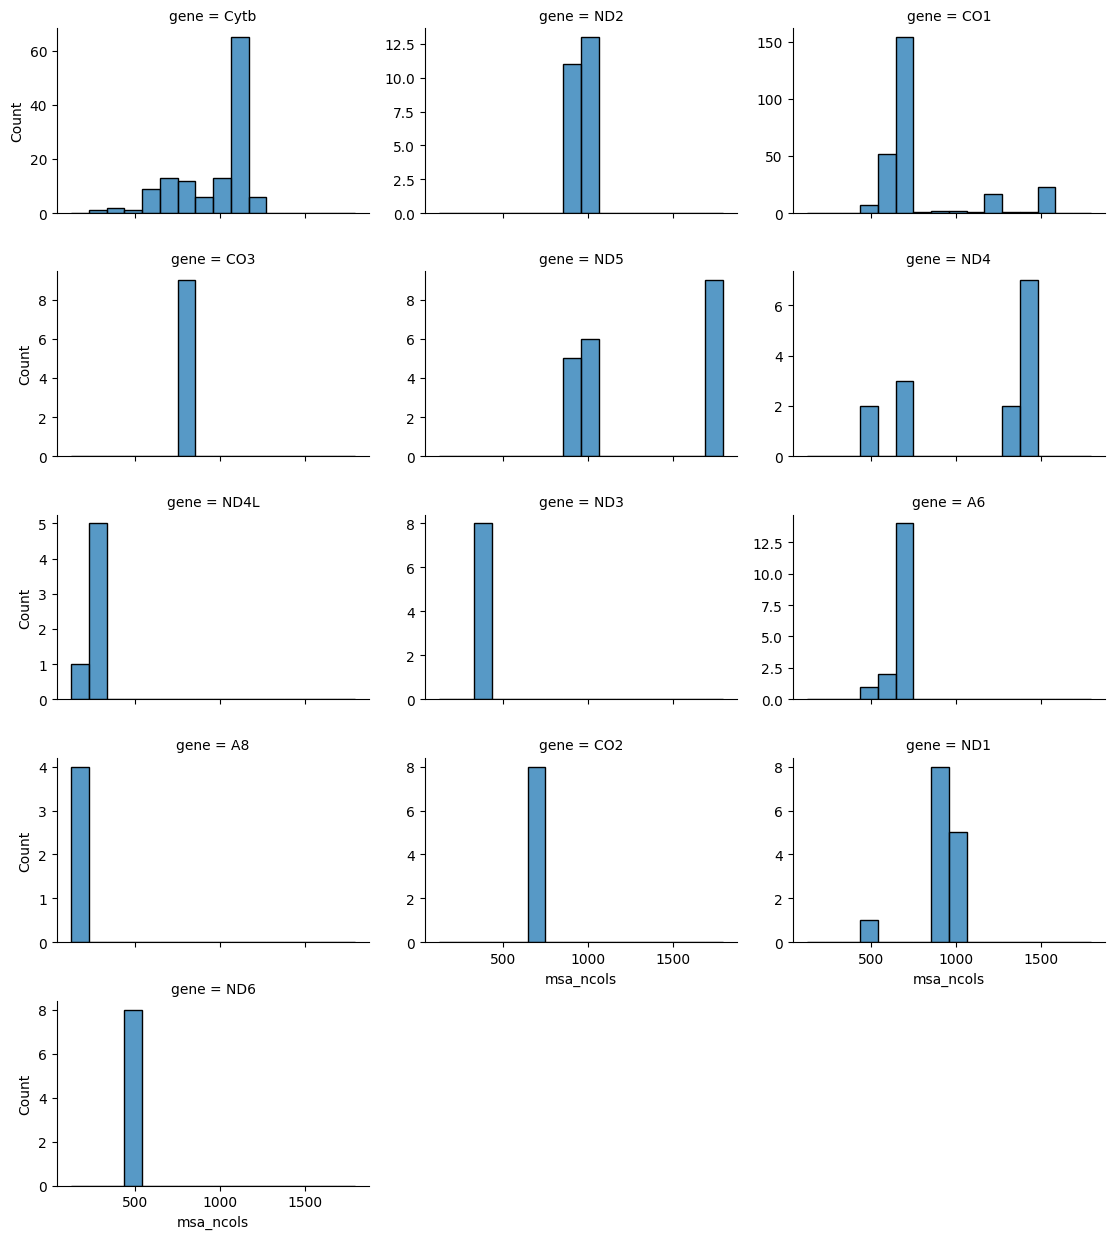

In [13]:
# Distributions of alignments lengths for each gene
# We see that some genes often partially sequences
# We need to filter out them to make our data and analyses homogeneous
g = sns.displot(data=exp_raw_df, x='msa_ncols', col='gene', col_order=_gene_order,
            height=2.5, aspect=1.5, col_wrap=3, kind='hist', facet_kws={'sharey': False})
g.savefig('./new_figures/dataset_msa_ncols_distributions.pdf')

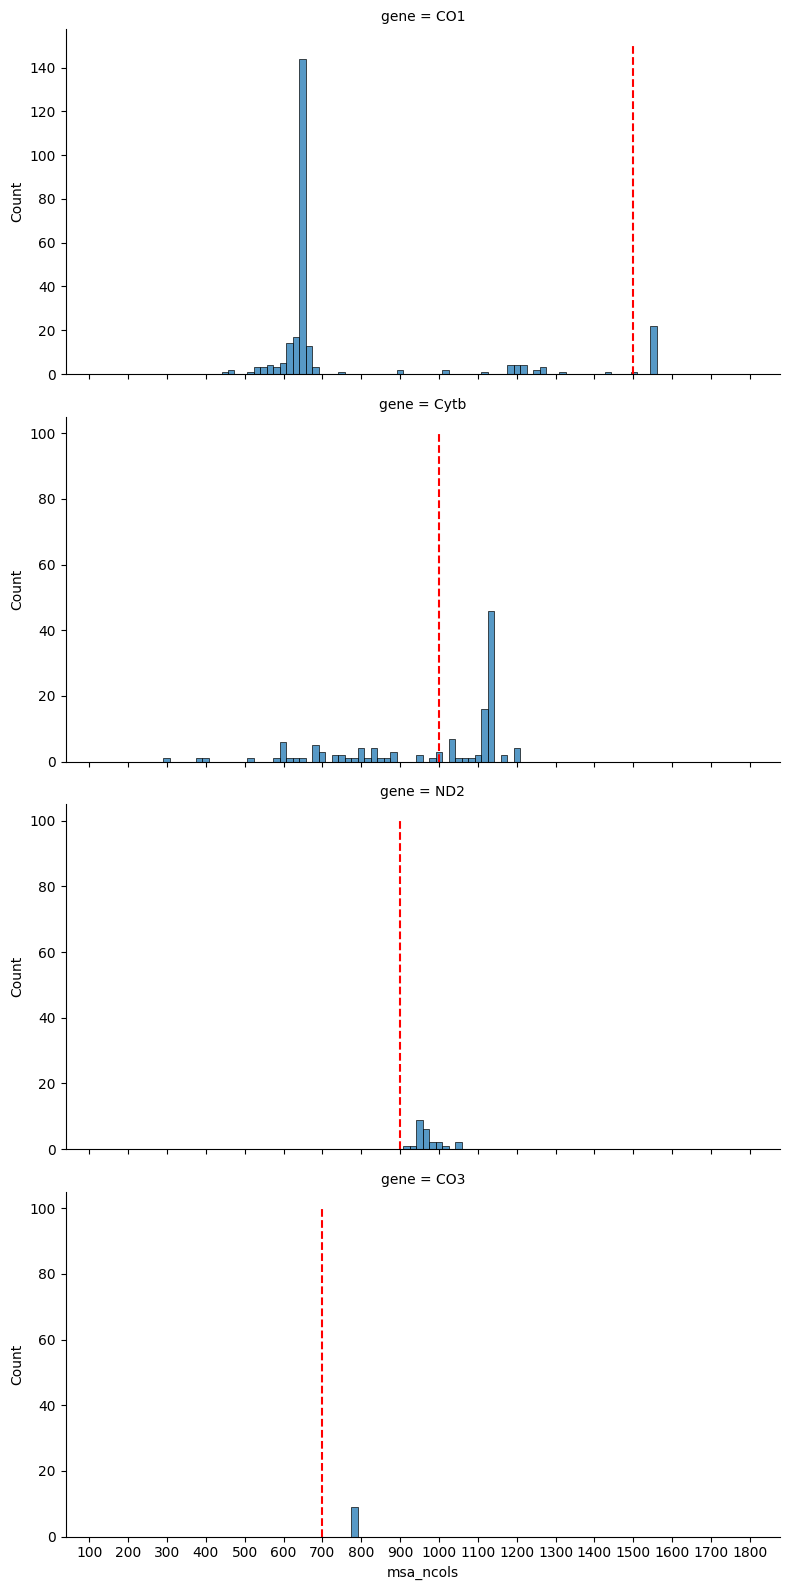

In [18]:
# msa ncols filtration cutoffs:
# images for supplements
cutoff_CO1  = 1500
cutoff_Cytb = 1000
cutoff_ND2  = 900
cutoff_CO3  = 700

g = sns.displot(data=exp_raw_df, x='msa_ncols', col='gene', col_order=['CO1', 'Cytb', 'ND2', 'CO3'],
            height=4, aspect=2, col_wrap=1, kind='hist', facet_kws={'sharey': False}, bins=100)
g.axes_dict['CO1'].set_xticks(np.arange(0, 1801, 100))
g.axes_dict['CO1'].vlines(cutoff_CO1, 0, 150, 'red', '--')
g.axes_dict['Cytb'].vlines(cutoff_Cytb, 0, 100, 'red', '--')
g.axes_dict['ND2'].vlines(cutoff_ND2, 0, 100, 'red', '--')
g.axes_dict['CO3'].vlines(cutoff_CO3, 0, 100, 'red', '--')
plt.savefig('./new_figures/selected_genes_length.png')
plt.show()

In [15]:
# table with gene alignments length distributions
exp_raw_df.groupby('gene').msa_ncols.describe()

,count,mean,std,min,25%,50%,75%,max
gene,,,,,,,,
A6,17.0,649.764706,66.170735,447.0,654.00,681.0,681.00,684.0
A8,4.0,152.250000,19.653244,123.0,150.00,160.5,162.75,165.0
CO1,261.0,769.425287,293.446639,450.0,648.00,651.0,657.00,1560.0
CO2,8.0,688.500000,4.242641,678.0,690.00,690.0,690.00,690.0
CO3,9.0,783.000000,0.000000,783.0,783.00,783.0,783.00,783.0
Cytb,128.0,979.664062,213.852450,306.0,810.00,1116.0,1140.00,1194.0
ND1,14.0,915.857143,118.481324,510.0,930.00,933.0,972.00,972.0
ND2,24.0,968.000000,32.367455,921.0,945.00,963.0,981.75,1044.0
ND3,8.0,348.000000,0.000000,348.0,348.00,348.0,348.00,348.0


### Clean up dataset!

Select 4 main genes and species that have nearly full sequence

In [19]:
# # msa ncols cutoffs:
#cutoff_CO1  = 1500
#cutoff_Cytb = 1000
#cutoff_ND2  = 900
#cutoff_CO3  = 700

sel_exp_genes = pd.concat([
    exp_raw_df[(exp_raw_df.gene == 'CO1') & (exp_raw_df.msa_ncols > cutoff_CO1)],
    exp_raw_df[(exp_raw_df.gene == 'Cytb') & (exp_raw_df.msa_ncols > cutoff_Cytb)],
    exp_raw_df[(exp_raw_df.gene == 'ND2') & (exp_raw_df.msa_ncols > cutoff_ND2)],
    exp_raw_df[(exp_raw_df.gene == 'CO3') & (exp_raw_df.msa_ncols > cutoff_CO3)],
])
print('Number of used species for selected genes')
sel_exp_genes.gene.value_counts()

Number of used species for selected genes


Cytb    82
ND2     24
CO1     23
CO3      9
Name: gene, dtype: int64

In [20]:
sel_exp_genes

,gene,species,msa_nseqs,msa_ncols,acgt_share,A>C,A>G,A>T,C>A,C>G,...,C[T>G]G,C[T>G]T,G[T>G]A,G[T>G]C,G[T>G]G,G[T>G]T,T[T>G]A,T[T>G]C,T[T>G]G,T[T>G]T
241,CO1,Schismatogobius_marmoratus,5,1551,1.000000,99.000000,144.800000,99.000000,75.400000,75.400000,...,9.800000,9.000000,2.000000,1.000000,5.000000,2.000000,9.000000,9.600000,7.000000,7.200000
250,CO1,Perccottus_glenii,6,1551,0.904255,91.833333,165.666667,91.833333,58.333333,58.333333,...,11.166667,6.666667,7.166667,0.833333,6.000000,5.500000,4.500000,8.000000,3.500000,5.166667
252,CO1,Rhinogobius_similis,17,1506,0.999883,93.470588,146.941176,93.470588,87.294118,87.294118,...,11.764706,7.588235,3.941176,0.882353,2.176471,0.764706,3.117647,10.411765,9.411765,5.588235
263,CO1,Eleotris_picta,4,1551,0.904255,83.750000,128.750000,83.750000,81.500000,81.500000,...,12.000000,7.500000,0.000000,0.000000,4.000000,0.000000,4.000000,4.000000,8.500000,3.500000
283,CO1,Sicyopterus_lagocephalus,4,1551,0.999516,115.250000,170.750000,115.250000,70.250000,70.250000,...,18.250000,6.000000,3.000000,1.000000,8.750000,2.000000,4.000000,10.000000,11.750000,6.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,CO3,Chaenogobius_annularis,63,783,0.993553,43.841270,78.095238,43.841270,34.746032,34.746032,...,10.476190,2.428571,1.952381,0.444444,2.031746,1.000000,3.412698,5.396825,4.952381,6.396825
206,CO3,Eleotris_fusca,9,783,1.000000,47.111111,86.222222,47.111111,50.777778,50.777778,...,3.000000,4.000000,1.000000,0.000000,0.111111,0.000000,1.000000,4.888889,4.000000,1.000000
207,CO3,Bostrychus_sinensis,8,783,1.000000,45.000000,83.875000,45.000000,63.500000,63.500000,...,2.625000,6.375000,0.000000,0.000000,0.750000,0.000000,0.500000,3.000000,3.500000,3.250000
208,CO3,Schismatogobius_ampluvinculus,15,783,1.000000,47.800000,80.733333,47.800000,47.533333,47.533333,...,5.000000,3.000000,0.000000,0.000000,2.933333,0.000000,0.000000,6.066667,4.200000,3.933333


### add family labels

In [20]:
#使用新分类的信息分配family
# 1. 读取原始元数据和外部属级分类文件
taxinfo = pd.read_csv('/home/zengjl/WorkSpace/mtdna-192component-mutspec-chordata/data/Gobiiformes/info.csv')
eschmeyer = pd.read_csv('/home/zengjl/WorkSpace/mtdna-192component-mutspec-chordata/data/Gobiiformes/Gobiidae_family_Eschmeyer.uniq.csv')

# 2. 清洗外部文件，构建属名→科的映射字典
#    注意：CSV 列名可能带有空格，我们统一 strip 一下
eschmeyer.columns = eschmeyer.columns.str.strip()
genus2family = dict(zip(eschmeyer['Genus'].str.strip(), eschmeyer['Family'].str.strip()))

# 3. 提取物种名中的属名（第一个单词）
taxinfo['species'] = taxinfo['species'].str.replace(' ', '_')
taxinfo['genus'] = taxinfo['species'].str.split('_').str[0]   # 属名（未清洗）

# 4. 定义“回退方案”的函数：优先用外部映射，找不到再用 NCBI 分类
def get_family(row):
    # 先尝试用属名查找权威科名
    genus = row['genus']
    if genus in genus2family:
        return genus2family[genus]
    # 若找不到，则用原始的 NCBI 分类提取科名
    taxa = row['taxa']
    parts = taxa.split(';')
    if len(parts) >= 4:
        # 第四个字段格式为 "Eleotridae_86197"
        family_raw = parts[3]  # 索引从0开始，0:Chordata, 1:Actinopteri, 2:Gobiiformes, 3:Family
        family_name = '_'.join(family_raw.split('_')[:-1])  # 去掉末尾 taxID
        return family_name
    return 'Unknown'

taxinfo['family'] = taxinfo.apply(get_family, axis=1)

# 5. 查看结果（可选删除辅助列 'genus'）
taxinfo = taxinfo.drop(columns=['genus'])
print("各科样本数：")
print(taxinfo['family'].value_counts().to_string())
taxinfo

各科样本数：
Oxudercidae      327
Gobiidae         267
Eleotridae        91
Odontobutidae      9
Milyeringidae      3


,acc,gene,taxa,species,family
0,OP759489.1.8107.8790_WEW79380.1,A6,Chordata_7711;Actinopteri_186623;Gobiiformes_1...,Bostrychus_sinensis,Eleotridae
1,KF413530.1.15.698_AHM93738.1,A6,Chordata_7711;Actinopteri_186623;Gobiiformes_1...,Oxyeleotris_lineolata,Eleotridae
2,KF413567.1.15.698_AHM93849.1,A6,Chordata_7711;Actinopteri_186623;Gobiiformes_1...,Oxyeleotris_selheimi,Eleotridae
3,MH463450.1.8079.8762_QCG70269.1,A6,Chordata_7711;Actinopteri_186623;Gobiiformes_1...,Eleotris_fusca,Eleotridae
4,AF227185.1.<1.>567_AAF87683.1,A6,Chordata_7711;Actinopteri_186623;Gobiiformes_1...,Hypseleotris_compressa,Eleotridae
...,...,...,...,...,...
692,AP018058.1.14301.13780_BBA12847.1,ND6,Chordata_7711;Actinopteri_186623;Gobiiformes_1...,Schismatogobius_ninja,Oxudercidae
693,LC564944.1.14297.13776_BCG68041.1,ND6,Chordata_7711;Actinopteri_186623;Gobiiformes_1...,Lentipes_armatus,Oxudercidae
694,LC564950.1.14298.13777_BCG68119.1,ND6,Chordata_7711;Actinopteri_186623;Gobiiformes_1...,Lentipes_kijimuna,Oxudercidae
695,LC564969.1.14298.13777_BCG68366.1,ND6,Chordata_7711;Actinopteri_186623;Gobiiformes_1...,Lentipes_palawanirufus,Oxudercidae


In [21]:
# distribution of families in this dataset
sel_exp_genes_cls = sel_exp_genes.merge(taxinfo.drop(['acc', 'taxa'], axis=1), on=['species', 'gene'])
sel_exp_genes_cls['family'].value_counts()

Oxudercidae      62
Gobiidae         42
Eleotridae       28
Odontobutidae     6
Name: family, dtype: int64

In [22]:
# use only 5 main families
#统计所有「科（family）」的样本数量 → 只保留样本最多的前 5 个主流科的数据 → 剔除所有稀有、小众的科
sel_exp_genes_cls = sel_exp_genes_cls[sel_exp_genes_cls['family']\
                                      .isin(sel_exp_genes_cls['family'].value_counts().index[:5])]

In [23]:
# distribution of species in the selected families
sel_exp_genes_cls['family'].value_counts()

Oxudercidae      62
Gobiidae         42
Eleotridae       28
Odontobutidae     6
Name: family, dtype: int64

In [24]:
# save cleaned expected mutations
sel_exp_genes_cls.to_csv('/home/zengjl/WorkSpace/mtdna-192component-mutspec-chordata/1data_derivation/new_dataset/expected.csv', index=False)

## Obs analysis and filtration

In [25]:
# load cleared exp mutations
expected = pd.read_csv('/home/zengjl/WorkSpace/mtdna-192component-mutspec-chordata/1data_derivation/new_dataset/expected.csv')
expected

,gene,species,msa_nseqs,msa_ncols,acgt_share,A>C,A>G,A>T,C>A,C>G,...,C[T>G]T,G[T>G]A,G[T>G]C,G[T>G]G,G[T>G]T,T[T>G]A,T[T>G]C,T[T>G]G,T[T>G]T,family
0,CO1,Schismatogobius_marmoratus,5,1551,1.000000,99.000000,144.800000,99.000000,75.400000,75.400000,...,9.000000,2.000000,1.000000,5.000000,2.000000,9.000000,9.600000,7.000000,7.200000,Oxudercidae
1,CO1,Perccottus_glenii,6,1551,0.904255,91.833333,165.666667,91.833333,58.333333,58.333333,...,6.666667,7.166667,0.833333,6.000000,5.500000,4.500000,8.000000,3.500000,5.166667,Odontobutidae
2,CO1,Rhinogobius_similis,17,1506,0.999883,93.470588,146.941176,93.470588,87.294118,87.294118,...,7.588235,3.941176,0.882353,2.176471,0.764706,3.117647,10.411765,9.411765,5.588235,Oxudercidae
3,CO1,Eleotris_picta,4,1551,0.904255,83.750000,128.750000,83.750000,81.500000,81.500000,...,7.500000,0.000000,0.000000,4.000000,0.000000,4.000000,4.000000,8.500000,3.500000,Eleotridae
4,CO1,Sicyopterus_lagocephalus,4,1551,0.999516,115.250000,170.750000,115.250000,70.250000,70.250000,...,6.000000,3.000000,1.000000,8.750000,2.000000,4.000000,10.000000,11.750000,6.000000,Oxudercidae
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,CO3,Chaenogobius_annularis,63,783,0.993553,43.841270,78.095238,43.841270,34.746032,34.746032,...,2.428571,1.952381,0.444444,2.031746,1.000000,3.412698,5.396825,4.952381,6.396825,Oxudercidae
134,CO3,Eleotris_fusca,9,783,1.000000,47.111111,86.222222,47.111111,50.777778,50.777778,...,4.000000,1.000000,0.000000,0.111111,0.000000,1.000000,4.888889,4.000000,1.000000,Eleotridae
135,CO3,Bostrychus_sinensis,8,783,1.000000,45.000000,83.875000,45.000000,63.500000,63.500000,...,6.375000,0.000000,0.000000,0.750000,0.000000,0.500000,3.000000,3.500000,3.250000,Eleotridae
136,CO3,Schismatogobius_ampluvinculus,15,783,1.000000,47.800000,80.733333,47.800000,47.533333,47.533333,...,3.000000,0.000000,0.000000,2.933333,0.000000,0.000000,6.066667,4.200000,3.933333,Oxudercidae


In [26]:
# load observed mutations, we should clear up it
obs_df = pd.read_csv('/home/zengjl/WorkSpace/mtdna-192component-mutspec-chordata/1data_derivation/new_dataset/raw_obs_muts.csv')
obs_df

,Mut,MutType,Site,PosInCodon,RefCodon,AltCodon,RefAa,AltAa,ProbaRef,ProbaMut,RefNode,AltNode,species,gene
0,C[C>A]A,2,135,3,CCC,CCA,P,P,0.999990,0.999990,Node6,seq_7,Bostrychus_sinensis,A8
1,C[A>C]C,0,112,1,ACC,CCC,T,P,0.997340,0.997340,Node1,seq_1,Bostrychus_sinensis,A8
2,C[T>C]C,2,132,3,GCT,GCC,A,A,0.895949,0.895949,Node1,seq_1,Bostrychus_sinensis,A8
3,C[A>G]A,2,66,3,ACA,ACG,T,T,0.999990,0.999980,Node2,Node3,Bostrychus_sinensis,A8
4,A[A>G]T,0,104,2,AAT,AGT,N,S,0.999990,0.999990,Node3,Node4,Bostrychus_sinensis,A8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25936,T[T>C]A,2,747,3,GTT,GTC,V,V,0.997260,0.997260,Node8,seq_11,Eleotris_fusca,ND4
25937,T[G>A]C,1,258,3,ATG,ATA,M,M,0.997290,0.997290,Node9,seq_7,Eleotris_fusca,ND4
25938,T[T>C]A,1,402,3,ATT,ATC,I,I,0.998680,0.998680,Node9,seq_7,Eleotris_fusca,ND4
25939,G[C>T]T,1,1045,1,CTA,TTA,L,L,0.998310,0.998310,Node9,seq_10,Eleotris_fusca,ND4


In [27]:
# 直接复用已经权威修正过family的taxinfo，确保分类正确且包含所有必要列
df_info = taxinfo.copy()
# 如果后续步骤需要统一 species 列的格式（例如将空格替换为下划线），可以再执行一次
df_info['species'] = df_info['species'].str.replace(' ', '_')
df_info

,acc,gene,taxa,species,family
0,OP759489.1.8107.8790_WEW79380.1,A6,Chordata_7711;Actinopteri_186623;Gobiiformes_1...,Bostrychus_sinensis,Eleotridae
1,KF413530.1.15.698_AHM93738.1,A6,Chordata_7711;Actinopteri_186623;Gobiiformes_1...,Oxyeleotris_lineolata,Eleotridae
2,KF413567.1.15.698_AHM93849.1,A6,Chordata_7711;Actinopteri_186623;Gobiiformes_1...,Oxyeleotris_selheimi,Eleotridae
3,MH463450.1.8079.8762_QCG70269.1,A6,Chordata_7711;Actinopteri_186623;Gobiiformes_1...,Eleotris_fusca,Eleotridae
4,AF227185.1.<1.>567_AAF87683.1,A6,Chordata_7711;Actinopteri_186623;Gobiiformes_1...,Hypseleotris_compressa,Eleotridae
...,...,...,...,...,...
692,AP018058.1.14301.13780_BBA12847.1,ND6,Chordata_7711;Actinopteri_186623;Gobiiformes_1...,Schismatogobius_ninja,Oxudercidae
693,LC564944.1.14297.13776_BCG68041.1,ND6,Chordata_7711;Actinopteri_186623;Gobiiformes_1...,Lentipes_armatus,Oxudercidae
694,LC564950.1.14298.13777_BCG68119.1,ND6,Chordata_7711;Actinopteri_186623;Gobiiformes_1...,Lentipes_kijimuna,Oxudercidae
695,LC564969.1.14298.13777_BCG68366.1,ND6,Chordata_7711;Actinopteri_186623;Gobiiformes_1...,Lentipes_palawanirufus,Oxudercidae


In [28]:
used_data = obs_df.merge(df_info).iloc[:, -5:].drop_duplicates()
#内容筛选'Gobiidae','Eleotridae','Odontobutidae'需要修改，基于实际情况
used_data = used_data[used_data['family'].isin(['Oxudercidae','Gobiidae','Eleotridae','Odontobutidae'])]
used_data['taxa'] = used_data['taxa'].str.replace('Chordata_7711;', '')
print(used_data.species.nunique())
used_data = used_data.set_index(['gene', 'family', 'species']).sort_index()
# used_data.to_csv('./data/supl_table1.csv')
used_data

354


acc  \
gene family      species                                                            
A6   Eleotridae  Bostrychus_sinensis              OP759489.1.8107.8790_WEW79380.1   
                 Eleotris_fusca                   MH463450.1.8079.8762_QCG70269.1   
                 Hypseleotris_compressa             AF227185.1.<1.>567_AAF87683.1   
                 Mogurnda_adspersa                KJ130031.1.8103.8786_AHM02317.1   
                 Mogurnda_mogurnda                 KC603688.1.159.>695_AHA42968.1   
...                                                                           ...   
ND6  Oxudercidae Lentipes_kijimuna              LC564950.1.14298.13777_BCG68119.1   
                 Lentipes_palawanirufus         LC564969.1.14298.13777_BCG68366.1   
                 Luciogobius_ryukyuensis        LC859293.1.14294.13773_BFW52198.1   
                 Schismatogobius_ampluvinculus  AP018095.1.14307.13786_BBA13327.1   
                 Taenioides_cirratus            KJ944420.1.14300.13779_AIQ78455.1   

                                                                                             taxa  
gene family      species                                                                           
A6   Eleotridae  Bostrychus_sinensis            Actinopteri_186623;Gobiiformes_1489878;Eleotri...  
                 Eleotris_fusca                 Actinopteri_186623;Gobiiformes_1489878;Eleotri...  
                 Hypseleotris_compressa         Actinopteri_186623;Gobiiformes_1489878;Eleotri...  
                 Mogurnda_adspersa              Actinopteri_186623;Gobiiformes_1489878;Eleotri...  
                 Mogurnda_mogurnda              Actinopteri_186623;Gobiiformes_1489878;Eleotri...  
...                                                                                           ...  
ND6  Oxudercidae Lentipes_kijimuna              Actinopteri_186623;Gobiiformes_1489878;Gobiida...  
                 Lentipes_palawanirufus         Actinopteri_186623;Gobiiformes_1489878;Gobiida...  
                 Luciogobius_ryukyuensis        Actinopteri_186623;Gobiiformes_1489878;Gobiida...  
                 Schismatogobius_ampluvinculus  Actinopteri_186623;Gobiiformes_1489878;Gobiida...  
                 Taenioides_cirratus            Actinopteri_186623;Gobiiformes_1489878;Gobiida...  

[495 rows x 2 columns]

In [29]:
# calculate the number of species that have mutational spectrum in each class and gene
x = obs_df.merge(df_info).groupby(['gene', 'family']).species.nunique().unstack()
#内容筛选'Gobiidae','Eleotridae','Odontobutidae'需要修改，基于实际情况
x = x[['Oxudercidae','Gobiidae','Eleotridae','Odontobutidae']]\
    .sort_values('Gobiidae', ascending=False).fillna(0).astype(int)
x.to_csv('./new_data/species_cnt_raw.csv')
x

family,Oxudercidae,Gobiidae,Eleotridae,Odontobutidae
gene,,,,
CO1,83,146,20,3
Cytb,62,38,16,2
ND2,7,8,7,2
ND1,8,4,2,0
A6,8,2,7,0
ND5,14,2,3,0
A8,1,1,1,0
CO2,6,0,2,0
CO3,6,0,2,0


In [30]:
# filter out non-syn mutations
obs_df = obs_df.merge(expected[['gene', 'species', 'family']], 
                      on=['gene', 'species'])
obs_df_syn = obs_df[obs_df.MutType > 0]
obs_df_syn

,Mut,MutType,Site,PosInCodon,RefCodon,AltCodon,RefAa,AltAa,ProbaRef,ProbaMut,RefNode,AltNode,species,gene,family
0,T[A>G]G,1,408,3,TTA,TTG,L,L,0.99819,0.99819,Node13,seq_8,Luciogobius_ryukyuensis,ND2,Oxudercidae
1,A[A>G]A,1,528,3,AAA,AAG,K,K,0.99819,0.99819,Node13,seq_8,Luciogobius_ryukyuensis,ND2,Oxudercidae
2,T[A>G]A,2,240,3,CTA,CTG,L,L,0.99997,0.99997,Node12,Node11,Luciogobius_ryukyuensis,ND2,Oxudercidae
4,A[A>G]G,1,351,3,GAA,GAG,E,E,0.99999,0.99998,Node9,Node8,Luciogobius_ryukyuensis,ND2,Oxudercidae
5,A[C>T]T,1,421,1,CTA,TTA,L,L,1.00000,1.00000,Node9,Node8,Luciogobius_ryukyuensis,ND2,Oxudercidae
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9937,C[T>C]T,2,1503,3,CCT,CCC,P,P,0.99999,0.99999,Node3,seq_2,Microdous_chalmersi,CO1,Odontobutidae
9938,A[A>G]C,1,1521,3,GAA,GAG,E,E,0.99999,0.99999,Node3,seq_2,Microdous_chalmersi,CO1,Odontobutidae
9939,T[T>A]A,2,123,3,CTT,CTA,L,L,1.00000,1.00000,Node8,seq_8,Microdous_chalmersi,CO1,Odontobutidae
9940,T[G>A]G,1,396,3,TTG,TTA,L,L,0.99999,0.99999,Node8,seq_8,Microdous_chalmersi,CO1,Odontobutidae


### Filter out outlier tree edges
(long branches)

In [31]:
# calculate number of mutations (estimate based on reconstructed probability)
# for each branch. We see outliers (max column)
edge_nobs = obs_df_syn.groupby(['gene', 'species', 'AltNode']).ProbaMut.sum().rename('edge_nobs')
edge_nobs_df = edge_nobs.reset_index()
edge_nobs_df.groupby('gene').describe().round(2)

edge_nobs                                           
         count  mean    std   min  25%  50%   75%     max
gene                                                     
CO1      217.0  4.04  14.11  0.49  1.0  1.0  2.85  179.00
CO3       90.0  1.45   0.87  0.63  1.0  1.0  1.99    5.00
Cytb    3163.0  1.88   3.57  0.33  1.0  1.0  2.00  110.00
ND2      388.0  2.41   4.43  0.34  1.0  1.0  2.00   60.25

In [32]:
# funcs for outliers filtrtation 
#计算「异常值分界线」
def get_iqr_bounds(series: pd.Series):
    # 计算下四分位数（所有数据从小到大排，前25%的位置）
    q1 = series.quantile(0.25)
    # 计算上四分位数（所有数据从小到大排，前75%的位置）
    q3 = series.quantile(0.75)
    # 四分位距（核心统计值，判断数据分布范围）
    iqr = q3 - q1
    # 异常值下界（几乎用不到，因为突变数不会异常少）
    lower_bound = q1 - 1.5 * iqr
    # 异常值上界（**核心！** 超过这个数 = 异常值）
    upper_bound = q3 + 1.5 * iqr
    # 返回上下边界
    return lower_bound, upper_bound

# 筛选正常数据，剔除异常值
def filter_outliers(data, column=None, max_val=None):
    # 第一步：判断输入格式，提取要过滤的数值列
    if isinstance(column, str) and isinstance(data, pd.DataFrame):
        series = data[column]
    elif isinstance(data, pd.Series):
        series = data
    else:
        raise Exception('incorrect input')

    # 第二步：调用上面的函数，计算异常值上边界
    _, upper_bound = get_iqr_bounds(series)
    
    # 第三步：保留 ≤ 上边界的数据（剔除异常大的值）
    filtered_data = data[(series <= upper_bound)]
    
    # 第四步：可选：额外设置一个最大值，双重过滤
    if max_val:
        filtered_data = filtered_data[(filtered_data[column] <= max_val)]
    
    # 返回清洗后的数据
    return filtered_data

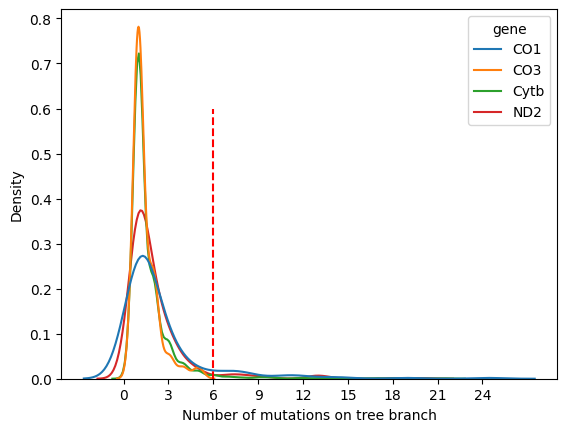

In [33]:
sns.kdeplot(data=edge_nobs_df[edge_nobs_df.edge_nobs<25], 
            x='edge_nobs', hue='gene', common_norm=False)
plt.vlines(6, 0, 0.6, 'r', '--')
plt.xticks(range(0, 27, 3))
plt.xlabel('Number of mutations on tree branch')
plt.savefig('./new_figures/tree_branch_mut_cnt.png')
plt.show()

In [34]:
#计算突变数的异常值边界（IQR统计法）
get_iqr_bounds(edge_nobs_df.edge_nobs)

(-0.5000599999999997, 3.5000199999999997)

In [35]:
#执行异常值过滤！得到【干净的进化树分支表格】
edge_nobs_df_flt = filter_outliers(edge_nobs_df, 'edge_nobs')
#查看过滤后，每个基因的分支突变数统计（均值/最大值等）  
edge_nobs_df_flt.groupby('gene').describe().round(2)

edge_nobs                                        
         count  mean   std   min  25%  50%   75%   max
gene                                                  
CO1      179.0  1.42  0.67  0.49  1.0  1.0  2.00  3.00
CO3       86.0  1.31  0.58  0.63  1.0  1.0  1.89  3.14
Cytb    2916.0  1.35  0.63  0.33  1.0  1.0  1.99  3.45
ND2      341.0  1.47  0.71  0.34  1.0  1.0  2.00  3.50

In [36]:
edge_nobs_df_flt

,gene,species,AltNode,edge_nobs
2,CO1,Bostrychus_sinensis,Node6,0.997960
3,CO1,Bostrychus_sinensis,Node7,0.981310
4,CO1,Bostrychus_sinensis,Node8,1.993664
5,CO1,Bostrychus_sinensis,Node9,0.996830
6,CO1,Bostrychus_sinensis,seq_1,1.090537
...,...,...,...,...
3853,ND2,Schismatogobius_ampluvinculus,seq_6,0.999990
3854,ND2,Schismatogobius_ampluvinculus,seq_7,1.000000
3855,ND2,Schismatogobius_ampluvinculus,seq_8,1.999980
3856,ND2,Schismatogobius_ampluvinculus,seq_9,1.941090


In [37]:
#统计：被过滤掉的突变总数 VS 保留的突变总数
edge_nobs[edge_nobs >= 6].sum(), edge_nobs[edge_nobs < 6].sum()

(2115.0472900000004, 5760.754133)

In [38]:
# 查看【过滤后】的突变数据总量，对比过滤前
obs_df_syn.shape, obs_df_syn['ProbaMut'].sum().round(2)

((8166, 15), 7875.8)

In [39]:
#合并数据！只保留正常分支的突变
obs_df_syn_edge_flt = obs_df_syn.merge(edge_nobs_df_flt, on=['gene', 'species', 'AltNode'])
#查看【过滤后】的突变数据总量，对比过滤前
obs_df_syn_edge_flt.shape, obs_df_syn_edge_flt['ProbaMut'].sum().round(2)

((4912, 16), 4813.18)

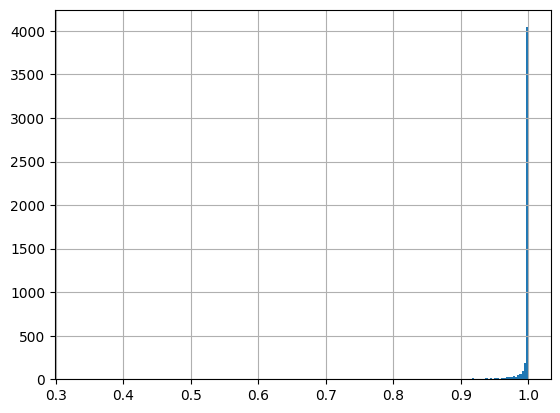

In [40]:
#X 轴：ProbaRef 的数值,NeMu 软件计算出的 参考碱基的概率（置信度）
#Y 轴：频数（Count / 数量）
obs_df_syn_edge_flt.ProbaRef.hist(bins=200);

### Filter out gene-species with low number of mutations (nobs>20)

In [41]:
#定义过滤阈值：每个物种、每个基因，**至少需要20个突变**才保留
NOBS_CUTOFF = 10  # required at least such number of mutations for each species
#按【基因 + 物种】分组，统计**总突变数量**
nobs = obs_df_syn_edge_flt.groupby(['gene', 'species']).ProbaMut.sum().rename('nobs')
#过滤：只保留**总突变数 ≥20**的物种/基因组合
nobs_flt = nobs[nobs >= NOBS_CUTOFF]
# 把统计结果转换成标准表格（方便后续使用）
nobs_flt_df = nobs_flt.reset_index()
#打印：过滤前的总数量 VS 过滤后的合格数量
print(nobs.shape, nobs_flt.shape)
nobs_flt.sum(level=0)

(126,) (79,)


gene
CO1      215.574848
CO3       99.374876
Cytb    3824.681830
ND2      434.502415
Name: nobs, dtype: float64

In [42]:
#before filtration
nobs.reset_index().groupby('gene').nobs.describe().round(2)

,count,mean,std,min,25%,50%,75%,max
gene,,,,,,,,
CO1,19.0,13.42,16.28,1.0,4.33,7.00,18.40,71.98
CO3,8.0,14.05,11.79,2.0,6.25,11.38,18.42,38.84
Cytb,75.0,52.57,71.56,1.0,9.15,23.46,68.05,386.48
ND2,24.0,20.95,44.40,1.0,6.19,8.21,17.84,224.29


In [43]:
#after filtration
nobs_flt_df.groupby('gene').nobs.describe().round(2)

,count,mean,std,min,25%,50%,75%,max
gene,,,,,,,,
CO1,9.0,23.95,18.81,10.92,13.06,19.81,23.65,71.98
CO3,5.0,19.87,11.27,10.99,11.76,17.95,19.83,38.84
Cytb,54.0,70.83,77.04,10.35,19.08,42.90,84.69,386.48
ND2,11.0,39.50,61.85,12.55,14.74,18.57,30.21,224.29


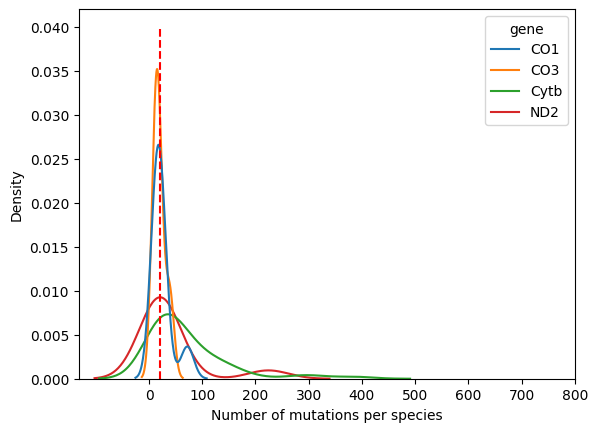

In [44]:
sns.kdeplot(data=nobs_flt_df, x='nobs', hue='gene', common_norm=False)
plt.vlines(20, 0, 0.04, 'r', '--')
plt.xticks(range(0, 801, 100))
plt.xlabel('Number of mutations per species')
plt.savefig('./new_figures/mut_cnt_per_species.png')
plt.show()

### Filer out gene-species with low number of mutational types in the spectra (nmuttype>10)

- total number of muttypes in 192-comp spectra is 192

In [45]:

NMUTTYPE_CUTOFF = 10 # required at least such number of mutation types for each species
nmuttype = obs_df_syn_edge_flt.groupby(['gene', 'species']).Mut.nunique().rename('nmuttype')
nmuttype_flt = nmuttype[nmuttype > NMUTTYPE_CUTOFF]
nmuttype_df = nmuttype.reset_index()
print(nmuttype.shape)
nmuttype_df.groupby('gene').nmuttype.describe()

(126,)


,count,mean,std,min,25%,50%,75%,max
gene,,,,,,,,
CO1,19.0,10.947368,9.969251,1.0,4.50,6.0,15.00,42.0
CO3,8.0,12.625000,9.500940,2.0,5.50,11.5,17.25,31.0
Cytb,75.0,26.386667,21.613868,1.0,9.00,20.0,38.00,84.0
ND2,24.0,12.750000,13.575073,1.0,6.75,9.0,16.00,67.0


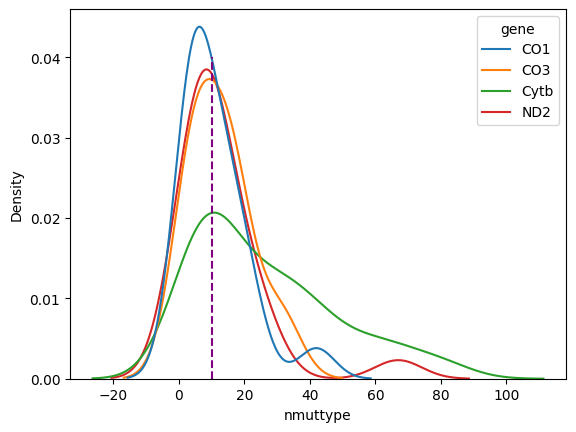

In [46]:
sns.kdeplot(data=nmuttype_df, x='nmuttype', hue='gene', common_norm=False)
plt.vlines(10, 0, 0.04, 'purple', '--', label='cutoff')
plt.show()

In [47]:
NMUTTYPE_CUTOFF = 10
ts = [x for x in possible_sbs192 if x[2:5] in ['C>T', 'T>C', 'G>A', 'A>G',]]

n_ts =  obs_df_syn_edge_flt[obs_df_syn_edge_flt.Mut.isin(ts)]\
    .groupby(['gene', 'species']).Mut.nunique().rename('n_ts')

n_ts_df = n_ts.reset_index()
print(n_ts.shape)
n_ts_df.groupby('gene').n_ts.describe()

(125,)


,count,mean,std,min,25%,50%,75%,max
gene,,,,,,,,
CO1,19.0,9.578947,8.597905,1.0,3.5,6.0,13.5,35.0
CO3,8.0,11.000000,8.502101,1.0,4.5,9.5,17.0,26.0
Cytb,75.0,21.040000,15.314222,1.0,8.5,16.0,31.5,56.0
ND2,23.0,10.956522,9.344314,1.0,6.0,8.0,14.5,44.0


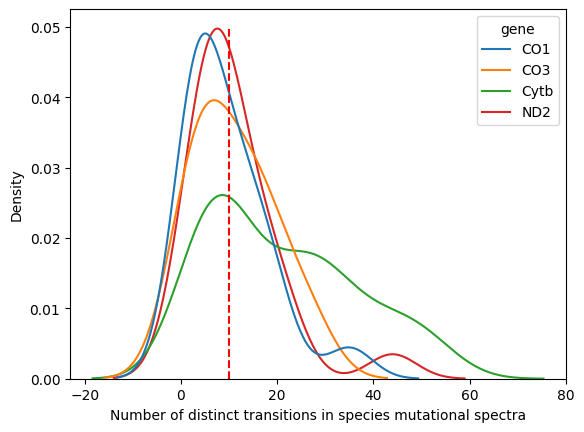

In [48]:
sns.kdeplot(data=n_ts_df, x='n_ts', hue='gene', common_norm=False)
plt.vlines(10, 0, 0.05, 'r', '--', label='cutoff')
plt.xlabel('Number of distinct transitions in species mutational spectra')
plt.savefig('./new_figures/ts_cnt_in_genes.png')
plt.show()

In [49]:
n_ts[n_ts > 10].shape, n_ts[n_ts <= 10].shape

((68,), (57,))

In [50]:
nmuttype[nmuttype > 10].shape, nmuttype[nmuttype <= 10].shape

((75,), (51,))

### Save obs muts table

In [51]:
obs_df_syn_edge_flt.shape

(4912, 16)

In [52]:
obs_df_syn_edge_flt.merge(
    nobs_flt_df.rename(columns={'nobs': 'species_nobs'}), 
    on=['gene', 'species']).shape

(4657, 17)

In [53]:
NOBS_CUTOFF = 10
NTS_CUTOFF  = 10
obs_df_syn_edge_flt_nobs_flt = obs_df_syn_edge_flt.merge(
        nobs[nobs >= NOBS_CUTOFF].reset_index().rename(columns={'nobs': 'species_nobs'}), 
        on=['gene', 'species'],
    ).merge(
        n_ts[n_ts >= NTS_CUTOFF].reset_index().rename(columns={'n_ts': 'species_n_ts'}), 
        on=['gene', 'species'],
    )
obs_df_syn_edge_flt_nobs_flt.shape

(4585, 18)

下述表格含义

行（index）：基因名（CO1, Cytb, ND2, CO3, A6 等）

列（columns）：科名（Gobiidae, Eleotridae, Odontobutidae 等）

单元格数值：该科内拥有该基因突变谱的物种数目（每个物种在每个基因下只会被计数一次）

In [54]:
obs_df_syn_edge_flt_nobs_flt.groupby(['gene', 'family']).species.nunique().unstack()

family,Eleotridae,Gobiidae,Odontobutidae,Oxudercidae
gene,,,,
CO1,2.0,NaN,NaN,7.0
CO3,NaN,NaN,NaN,4.0
Cytb,12.0,17.0,2.0,19.0
ND2,1.0,3.0,NaN,6.0


In [55]:
obs_df_syn_edge_flt_nobs_flt.groupby(['gene', 'family']).ProbaMut.sum().round().unstack()

family,Eleotridae,Gobiidae,Odontobutidae,Oxudercidae
gene,,,,
CO1,25.0,NaN,NaN,191.0
CO3,NaN,NaN,NaN,88.0
Cytb,913.0,1178.0,275.0,1412.0
ND2,19.0,46.0,NaN,357.0


### Check ts/tv ratio of observed mutations 

In [56]:
ts = [x for x in possible_sbs192 if x[2:5] in ['C>T', 'T>C', 'G>A', 'A>G',]]

In [57]:
obs_df_syn_edge_flt_nobs_flt['is_ts'] = obs_df_syn_edge_flt_nobs_flt.Mut.isin(ts)
obs_df_syn_edge_flt_nobs_flt

,Mut,MutType,Site,PosInCodon,RefCodon,AltCodon,RefAa,AltAa,ProbaRef,ProbaMut,RefNode,AltNode,species,gene,family,edge_nobs,species_nobs,species_n_ts,is_ts
0,T[A>G]G,1,408,3,TTA,TTG,L,L,0.99819,0.99819,Node13,seq_8,Luciogobius_ryukyuensis,ND2,Oxudercidae,1.99638,13.947110,11,True
1,A[A>G]A,1,528,3,AAA,AAG,K,K,0.99819,0.99819,Node13,seq_8,Luciogobius_ryukyuensis,ND2,Oxudercidae,1.99638,13.947110,11,True
2,T[A>G]A,2,240,3,CTA,CTG,L,L,0.99997,0.99997,Node12,Node11,Luciogobius_ryukyuensis,ND2,Oxudercidae,0.99997,13.947110,11,True
3,T[G>A]A,2,366,3,CTG,CTA,L,L,0.99999,0.99999,Node10,seq_14,Luciogobius_ryukyuensis,ND2,Oxudercidae,0.99999,13.947110,11,True
4,C[A>G]G,2,771,3,ACA,ACG,T,T,0.99923,0.99923,Node8,seq_4,Luciogobius_ryukyuensis,ND2,Oxudercidae,0.99923,13.947110,11,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4580,T[T>C]C,1,735,3,ATT,ATC,I,I,1.00000,1.00000,Node9,seq_13,Bostrychus_sinensis,CO1,Eleotridae,2.00000,13.060251,11,True
4581,G[A>G]A,2,789,3,GGA,GGG,G,G,1.00000,1.00000,Node9,seq_13,Bostrychus_sinensis,CO1,Eleotridae,2.00000,13.060251,11,True
4582,T[G>C]T,2,861,3,GTG,GTC,V,V,1.00000,1.00000,Node10,seq_8,Bostrychus_sinensis,CO1,Eleotridae,1.00000,13.060251,11,False
4583,G[G>A]G,2,678,3,GGG,GGA,G,G,1.00000,1.00000,Node12,seq_10,Bostrychus_sinensis,CO1,Eleotridae,1.00000,13.060251,11,True


In [58]:
ts_frac = obs_df_syn_edge_flt_nobs_flt\
    .groupby(['family', 'gene', 'species']).is_ts\
        .value_counts(normalize=True).unstack()[True].rename('ts_frac')
ts_frac

family       gene  species                      
Eleotridae   CO1   Bostrychus_sinensis              0.800000
                   Eleotris_fusca                   0.916667
             Cytb  Bostrychus_sinensis              0.899371
                   Dormitator_latifrons             0.814815
                   Dormitator_maculatus             0.897059
                                                      ...   
Oxudercidae  ND2   Lentipes_armatus                 0.875000
                   Lentipes_palawanirufus           0.862069
                   Luciogobius_ryukyuensis          1.000000
                   Pterogobius_elapoides            0.868421
                   Schismatogobius_ampluvinculus    0.952381
Name: ts_frac, Length: 73, dtype: float64

In [59]:
print('Ts mean share')
ts_frac.mean(level=[0,1]).unstack()

Ts mean share


gene,CO1,CO3,Cytb,ND2
family,,,,
Eleotridae,0.858333,NaN,0.869635,0.863636
Gobiidae,NaN,NaN,0.890102,0.947368
Odontobutidae,NaN,NaN,0.638718,NaN
Oxudercidae,0.933320,0.905623,0.894985,0.905663


In [60]:
# same on unfiltered obs mut dataset
obs_df_syn['is_ts'] = obs_df_syn.Mut.isin(ts)
print('Ts mean share (unfiltered dataset)')
obs_df_syn.groupby(['family', 'gene', 'species']).is_ts\
        .value_counts(normalize=True).unstack()\
            .mean(level=[0,1])[True].unstack()

Ts mean share (unfiltered dataset)


gene,CO1,CO3,Cytb,ND2
family,,,,
Eleotridae,0.904971,0.708333,0.875330,0.839175
Gobiidae,1.000000,NaN,0.884072,0.932261
Odontobutidae,0.852688,NaN,0.669706,0.854839
Oxudercidae,0.849429,0.876156,0.884239,0.887054


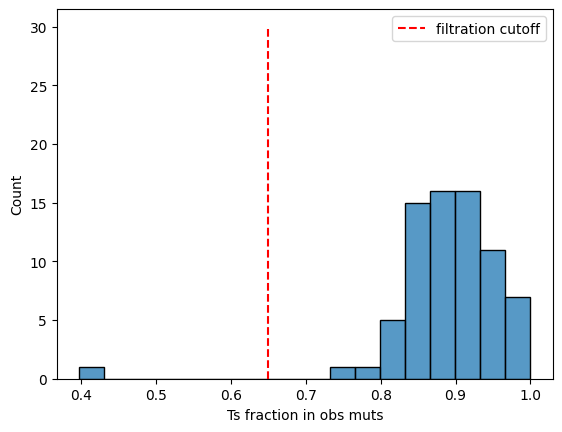

In [61]:
# sns.kdeplot(obs_df_syn.groupby(['class', 'gene', 'species']).is_ts\
#         .value_counts(normalize=True).unstack()[True])
sns.histplot(ts_frac).set_xlabel('Ts fraction in obs muts')
plt.vlines(0.65, 0, 30, 'r', '--', label='filtration cutoff')
plt.legend()
plt.savefig('./new_figures/ts_frac_filter.png')
plt.show()

In [62]:
final_obs = obs_df_syn_edge_flt_nobs_flt.merge(
    ts_frac[ts_frac > 0.65].reset_index(), 
    on=['family', 'gene', 'species'])
obs_df_syn_edge_flt_nobs_flt.shape, final_obs.shape

((4585, 19), (4429, 20))

In [63]:
# save final cleaned dataset of observed mutations
final_obs.to_csv('/home/zengjl/WorkSpace/mtdna-192component-mutspec-chordata/1data_derivation/new_dataset/obs_muts.csv', index=False)

#### Explore outlayers according to Ts share

In [64]:
#筛选异常样本，ts_frac = 转换 / 颠换比率（Ts/Tv），低于0.75为异常
ts_frac[ts_frac.between(0., 0.75)].sort_values().reset_index()

,family,gene,species,ts_frac
0,Odontobutidae,Cytb,Odontobutis_potamophilus,0.397436
1,Gobiidae,Cytb,Neogobius_pallasi,0.743243


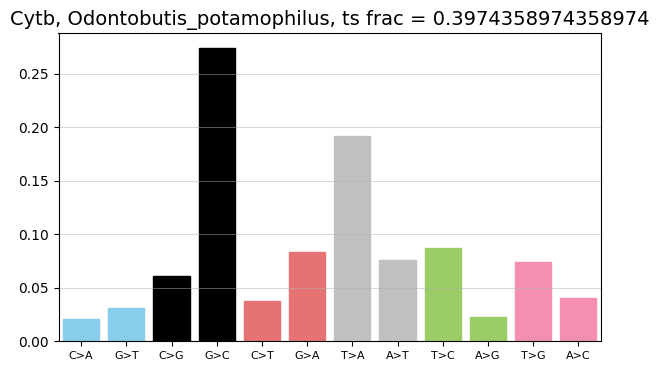

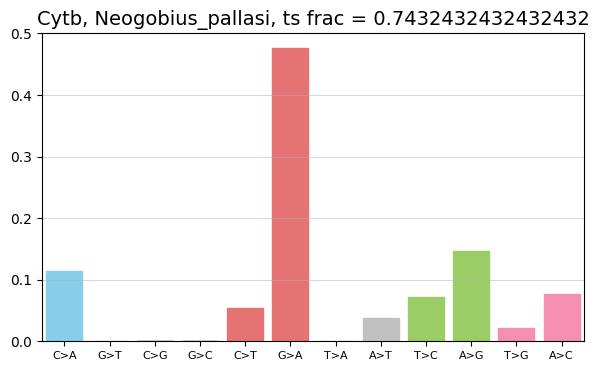

In [65]:
for i, x in ts_frac[ts_frac.between(0., 0.75)].sort_values().reset_index().iterrows():
    o = obs_df_syn_edge_flt_nobs_flt[
        (obs_df_syn_edge_flt_nobs_flt.species == x['species']) &
        (obs_df_syn_edge_flt_nobs_flt.gene == x['gene'])
    ]
    o = o.rename(columns={'ProbaMut': 'ProbaFull'})
    assert o.gene.nunique() == 1
    e = expected[
        (expected.species == x['species']) & 
        (expected.gene == x['gene'])
    ]
    e12  = e[possible_sbs12].reset_index(drop=True).T[0].to_dict()
    ms12 = calculate_mutspec(o, e12, use_proba=True)
    e192 = e[possible_sbs192].reset_index(drop=True).T[0].to_dict()
    ms192 = calculate_mutspec(o, e192, True, True)

    plot_mutspec12(
        ms12[ms12.ExpNum > 1], figsize=(7, 4),
        title=f"{x['gene']}, {x['species']}, ts frac = {x['ts_frac']}");

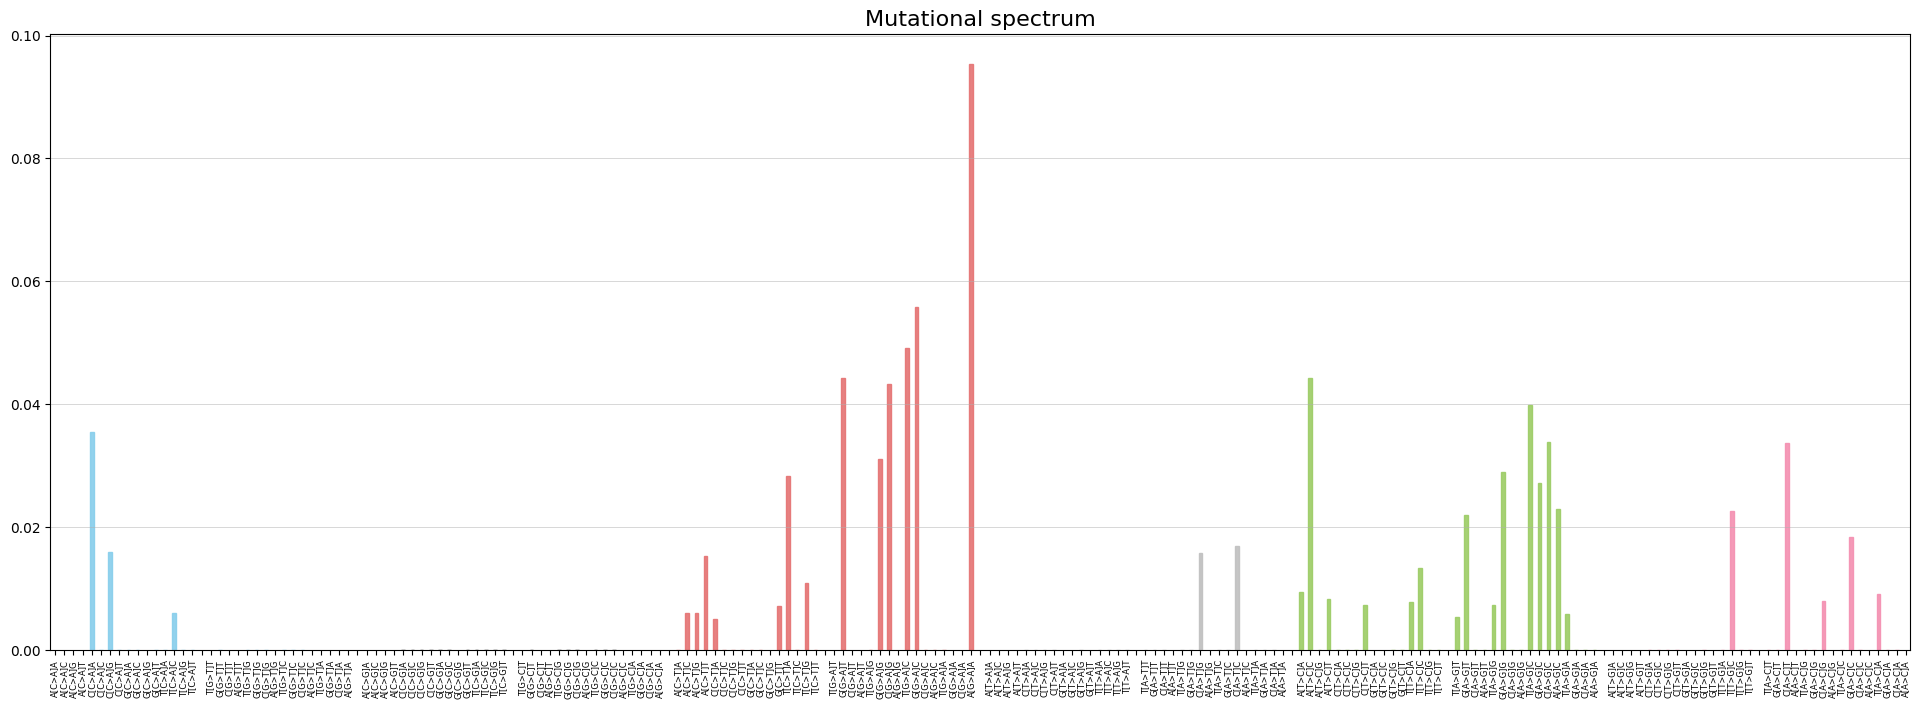

In [117]:
plot_mutspec192(ms192[ms192.ExpNum > 1]);

## Calculate mutational spectrum based on cleaned observed and expected mutations

In [66]:
exp_freqs = pd.read_csv('/home/zengjl/WorkSpace/mtdna-192component-mutspec-chordata/1data_derivation/new_dataset/expected.csv')
obs = pd.read_csv('/home/zengjl/WorkSpace/mtdna-192component-mutspec-chordata/1data_derivation/new_dataset/obs_muts.csv')
obs['sbs12'] = obs.Mut.str.slice(2, 5)

In [67]:
# check abcense of non-syn mutations (0 value)
obs.MutType.value_counts()

2    2662
1    1767
Name: MutType, dtype: int64

### calculate 12-component spectrum

In [68]:
# reformat to similar wide tables
_mut_col = 'sbs12'
exp_long = exp_freqs.set_index(['gene', 'family', 'species'])[possible_sbs12]\
    .melt(ignore_index=False, var_name=_mut_col, value_name='Expected').reset_index()
obs_long = obs.groupby(['gene', 'family', 'species', _mut_col])['ProbaMut'].sum()\
    .rename('Observed').reset_index()

# merge obs and exp; exp will fill all unobserved mut types and species
spectra12 = obs_long.merge(exp_long, 'right', ['gene', 'family', 'species', _mut_col])

# filter out unobserved species
observed_species = spectra12.set_index(['gene', 'species', _mut_col])\
    .Observed.unstack().sum(axis=1)
observed_species = observed_species[observed_species > 0].index.to_frame(index=False)
spectra12 = spectra12.merge(observed_species)

spectra12.rename(
    columns={'gene': 'Gene', 'family': 'family', 
             'species': 'Species', _mut_col: 'Mut'},
    inplace=True)
spectra12['RawMutSpec'] = spectra12['Observed'] / spectra12['Expected']

RawMutSpec = spectra12.groupby(['Gene', 'family', 'Species'])\
    .RawMutSpec.sum().rename('RawMutSpecSum')
spectra12 = spectra12.merge(RawMutSpec, on=['Gene', 'family', 'Species'])

spectra12['MutSpec'] = (spectra12['RawMutSpec'] / spectra12['RawMutSpecSum']).fillna(0.)
spectra12.drop(['RawMutSpec', 'RawMutSpecSum'], axis=1, inplace=True)
spectra12

,Gene,family,Species,Mut,Observed,Expected,MutSpec
0,CO1,Oxudercidae,Rhinogobius_similis,A>C,NaN,93.470588,0.000000
1,CO1,Oxudercidae,Rhinogobius_similis,A>G,1.999500,146.941176,0.054399
2,CO1,Oxudercidae,Rhinogobius_similis,A>T,NaN,93.470588,0.000000
3,CO1,Oxudercidae,Rhinogobius_similis,C>A,NaN,87.294118,0.000000
4,CO1,Oxudercidae,Rhinogobius_similis,C>G,0.999950,87.294118,0.045794
...,...,...,...,...,...,...,...
859,CO3,Oxudercidae,Lentipes_palawanirufus,G>C,NaN,9.583333,0.000000
860,CO3,Oxudercidae,Lentipes_palawanirufus,G>T,NaN,9.583333,0.000000
861,CO3,Oxudercidae,Lentipes_palawanirufus,T>A,NaN,25.000000,0.000000
862,CO3,Oxudercidae,Lentipes_palawanirufus,T>C,2.985073,59.583333,0.127871


In [69]:
spectra12.groupby(['Gene', 'Species']).Observed.min().sort_values()

Gene  Species                      
CO3   Taenioides_cirratus              0.332240
Cytb  Bathygobius_geminatus            0.350160
      Bathygobius_soporator            0.490291
      Hypseleotris_gymnocephala        0.503454
      Gobius_fallax                    0.604922
                                         ...   
      Schismatogobius_ampluvinculus    2.000000
ND2   Pterogobius_elapoides            2.000000
Cytb  Chaenogobius_annularis           2.760490
      Rhinogobius_nagoyae              2.990450
      Knipowitschia_goerneri           2.999340
Name: Observed, Length: 72, dtype: float64

In [70]:
# all spectra sum = 1
assert np.allclose(spectra12.groupby(['Gene', 'Species']).MutSpec.sum(), 1)

In [71]:
# 42% of zeros in 12-comp spectra
spectra12.MutSpec.eq(0.).value_counts(normalize=True)

False    0.579861
True     0.420139
Name: MutSpec, dtype: float64

### same on 192-comp spectra

In [72]:
_mut_col = 'Mut'
exp_long = exp_freqs.set_index(['gene', 'family', 'species'])[possible_sbs192]\
    .melt(ignore_index=False, var_name=_mut_col, value_name='Expected').reset_index()
obs_long = obs.groupby(['gene', 'family', 'species', _mut_col])['ProbaMut'].sum()\
    .rename('Observed').reset_index()

# merge obs and exp; exp will fill all unobserved mut types and species
spectra192 = obs_long.merge(exp_long, 'right', ['gene', 'family', 'species', _mut_col])
# filter out unobserved species
observed_species = spectra192.set_index(['gene', 'species', _mut_col])\
    .Observed.unstack().sum(axis=1)
observed_species = observed_species[observed_species > 0].index.to_frame(index=False)
spectra192 = spectra192.merge(observed_species)

spectra192.rename(
    columns={'gene': 'Gene', 'family': 'family', 'species': 'Species'},
    inplace=True)

spectra192['RawMutSpec'] = (spectra192['Observed'].fillna(0.) / \
                            spectra192['Expected'].fillna(0.))
spectra192['RawMutSpec'] = spectra192['RawMutSpec'].replace(np.inf, 0.).fillna(0.)
assert spectra192.RawMutSpec.isna().sum() == 0

RawMutSpecSum = spectra192.groupby(['Gene', 'family', 'Species'])\
    .RawMutSpec.sum().rename('RawMutSpecSum')

spectra192 = spectra192.merge(RawMutSpecSum, on=['Gene', 'family', 'Species'])
spectra192['MutSpec'] = (spectra192['RawMutSpec'] / spectra192['RawMutSpecSum']).fillna(0.)
spectra192.drop(['RawMutSpec', 'RawMutSpecSum'], axis=1, inplace=True)
spectra192

,Gene,family,Species,Mut,Observed,Expected,MutSpec
0,CO1,Oxudercidae,Rhinogobius_similis,A[A>C]A,NaN,0.0,0.0
1,CO1,Oxudercidae,Rhinogobius_similis,A[A>C]C,NaN,0.0,0.0
2,CO1,Oxudercidae,Rhinogobius_similis,A[A>C]G,NaN,0.0,0.0
3,CO1,Oxudercidae,Rhinogobius_similis,A[A>C]T,NaN,0.0,0.0
4,CO1,Oxudercidae,Rhinogobius_similis,C[A>C]A,NaN,12.0,0.0
...,...,...,...,...,...,...,...
13819,CO3,Oxudercidae,Lentipes_palawanirufus,G[T>G]T,NaN,0.0,0.0
13820,CO3,Oxudercidae,Lentipes_palawanirufus,T[T>G]A,NaN,1.0,0.0
13821,CO3,Oxudercidae,Lentipes_palawanirufus,T[T>G]C,NaN,3.0,0.0
13822,CO3,Oxudercidae,Lentipes_palawanirufus,T[T>G]G,NaN,5.0,0.0


In [73]:
spectra192.groupby(['Gene', 'Species']).Observed.min().sort_values()

Gene  Species                  
CO3   Taenioides_cirratus          0.332240
CO1   Bostrychus_sinensis          0.341599
Cytb  Bathygobius_geminatus        0.350160
      Hypseleotris_gymnocephala    0.382985
CO3   Chaenogobius_annularis       0.392548
                                     ...   
Cytb  Periophthalmus_waltoni       0.999510
CO1   Chaenogobius_annularis       0.999710
Cytb  Proterorhinus_marmoratus     0.999750
      Awaous_stamineus             0.999780
      Gobius_geniporus             0.999840
Name: Observed, Length: 72, dtype: float64

In [74]:
assert np.allclose(spectra192.groupby(['Gene', 'Species']).MutSpec.sum(), 1)

In [75]:
# 17% of zeros in 192-comp spectra - sparse dataset
spectra192.MutSpec.eq(0.).value_counts(normalize=True)

True     0.839916
False    0.160084
Name: MutSpec, dtype: float64

In [76]:
print('Species count with 192-comp spectrum')
spectra192.groupby(['Gene', 'family']).Species.nunique().unstack()

Species count with 192-comp spectrum


family,Eleotridae,Gobiidae,Odontobutidae,Oxudercidae
Gene,,,,
CO1,2.0,NaN,NaN,7.0
CO3,NaN,NaN,NaN,4.0
Cytb,12.0,17.0,1.0,19.0
ND2,1.0,3.0,NaN,6.0


In [77]:
# save final tables that used un the article
spectra12.to_csv('/home/zengjl/WorkSpace/mtdna-192component-mutspec-chordata/1data_derivation/new_dataset/MutSpecGobiiformes12.csv.gz', 
                 index=False, compression='gzip')
spectra192.to_csv('/home/zengjl/WorkSpace/mtdna-192component-mutspec-chordata/1data_derivation/new_dataset/MutSpecGobiiformes192.csv.gz', 
                  index=False, compression='gzip')

In [78]:
# get species table
species = spectra192[['Gene', 'family', 'Species']].drop_duplicates()
species.columns = species.columns.str.lower()
species

,gene,family,species
0,CO1,Oxudercidae,Rhinogobius_similis
192,CO1,Eleotridae,Eleotris_fusca
384,CO1,Oxudercidae,Schismatogobius_ampluvinculus
576,CO1,Oxudercidae,Chaenogobius_annularis
768,CO1,Oxudercidae,Lentipes_kijimuna
...,...,...,...
12864,ND2,Eleotridae,Hypseleotris_klunzingeri
13056,CO3,Oxudercidae,Taenioides_cirratus
13248,CO3,Oxudercidae,Chaenogobius_annularis
13440,CO3,Oxudercidae,Schismatogobius_ampluvinculus


In [79]:
# save gene-class species counts in derived dataset
_scpesies_cnt = species.groupby(['gene', 'family']).species.count().unstack()
_scpesies_cnt.to_csv('./new_data/species_cnt_filtered.csv')
_scpesies_cnt

family,Eleotridae,Gobiidae,Odontobutidae,Oxudercidae
gene,,,,
CO1,2.0,NaN,NaN,7.0
CO3,NaN,NaN,NaN,4.0
Cytb,12.0,17.0,1.0,19.0
ND2,1.0,3.0,NaN,6.0


## Compare new spectra with old one
Required for first revision

Here we visuzlized in L-strand style

### Class-specific spectra

In [136]:
old_dataset = pd.read_csv('../data/legacy/MutSpecVertebratescytb.csv')
old_dataset['Mut'] = old_dataset['Mut'].apply(rev_comp)
old_dataset['Class'] = old_dataset['Class'].str.replace('Actinopterygii', 'Actinopteri')
new_dataset = pd.read_csv('../data/new_dataset/MutSpecVertebrates192.csv.gz')
new_dataset = new_dataset[new_dataset.Gene == 'Cytb'].drop('Gene', axis=1)

old_dataset.shape, new_dataset.shape

FileNotFoundError: [Errno 2] No such file or directory: '../data/legacy/MutSpecVertebratescytb.csv'

In [65]:
new_cls_spectra = new_dataset.set_index(['Class', 'Species', 'Mut'])\
    .MutSpec.unstack().mean(level=0)

old_cls_spectra = old_dataset.set_index(['Class', 'Species', 'Mut'])\
    .MutSpec.unstack().mean(level=0)

assert (new_cls_spectra.columns == old_cls_spectra.columns).all()
assert (new_cls_spectra.index == old_cls_spectra.index).all()

In [66]:
new_cls_spectra_indexed = new_cls_spectra.assign(Ver='New')\
    .set_index('Ver', append=True)\
        .reorder_levels(['Ver', 'Class'])

old_cls_spectra_indexed = old_cls_spectra.assign(Ver='Old')\
    .set_index('Ver', append=True)\
        .reorder_levels(['Ver', 'Class'])

old_vs_new_cls_sim = pd.DataFrame(
    1-cdist(old_cls_spectra_indexed, new_cls_spectra_indexed, 'cosine'), 
    columns=new_cls_spectra_indexed.index, 
    index=old_cls_spectra_indexed.index)

old_vs_new_cls_sim.to_csv('../data/old_vs_new_cls_sim.csv')
old_vs_new_cls_sim

Ver                      New                                           
Class            Actinopteri  Amphibia      Aves Lepidosauria  Mammalia
Ver Class                                                              
Old Actinopteri     0.945882  0.910960  0.926553     0.933037  0.955325
    Amphibia        0.875253  0.874181  0.880522     0.863497  0.899039
    Aves            0.747335  0.719376  0.903301     0.785291  0.844504
    Lepidosauria    0.839757  0.822437  0.887349     0.883506  0.894081
    Mammalia        0.872016  0.871834  0.949382     0.907463  0.953148

#### Plot some classes spectra old and new

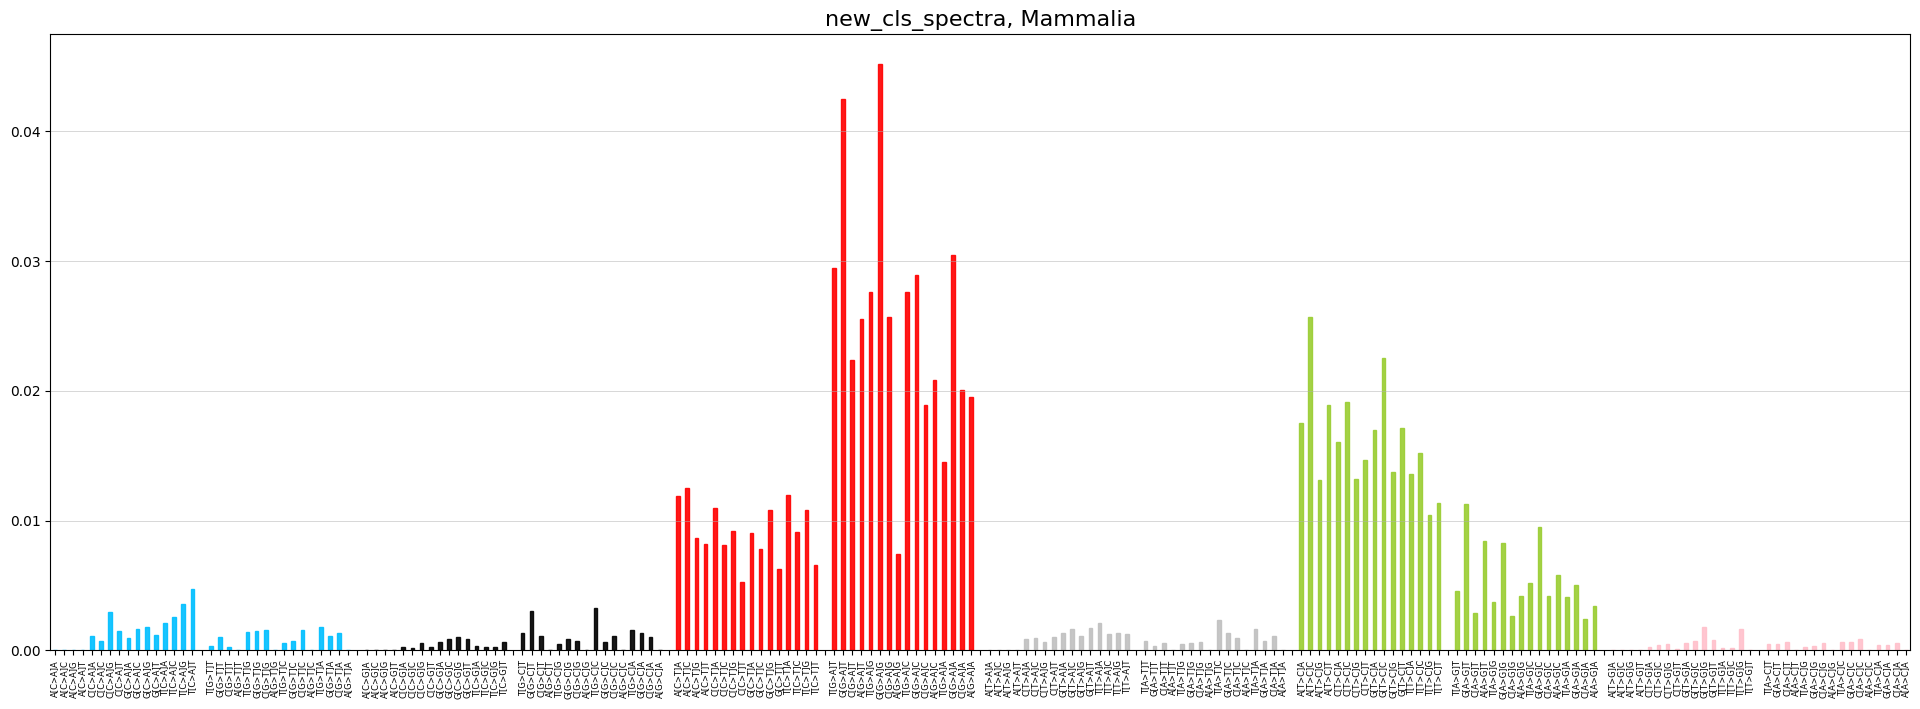

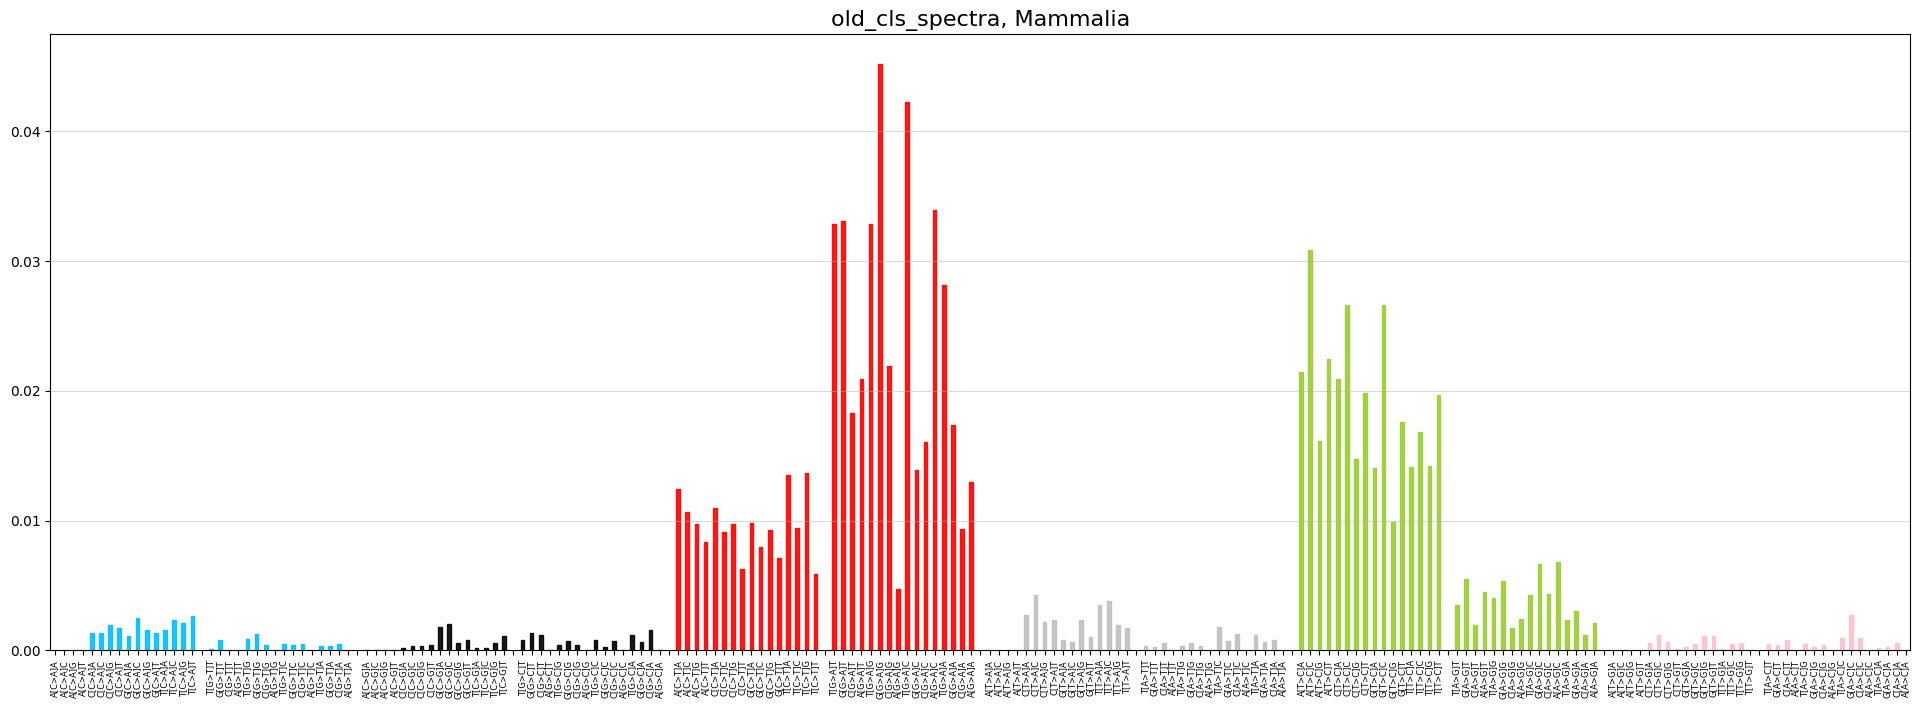

<AxesSubplot:title={'center':'old_cls_spectra, Mammalia'}>

In [ ]:
plot_mutspec192(new_cls_spectra.loc['Mammalia'].rename('MutSpec').reset_index(), 
                title='new_cls_spectra, Mammalia')
plot_mutspec192(old_cls_spectra.loc['Mammalia'].rename('MutSpec').reset_index(), 
                title='old_cls_spectra, Mammalia');

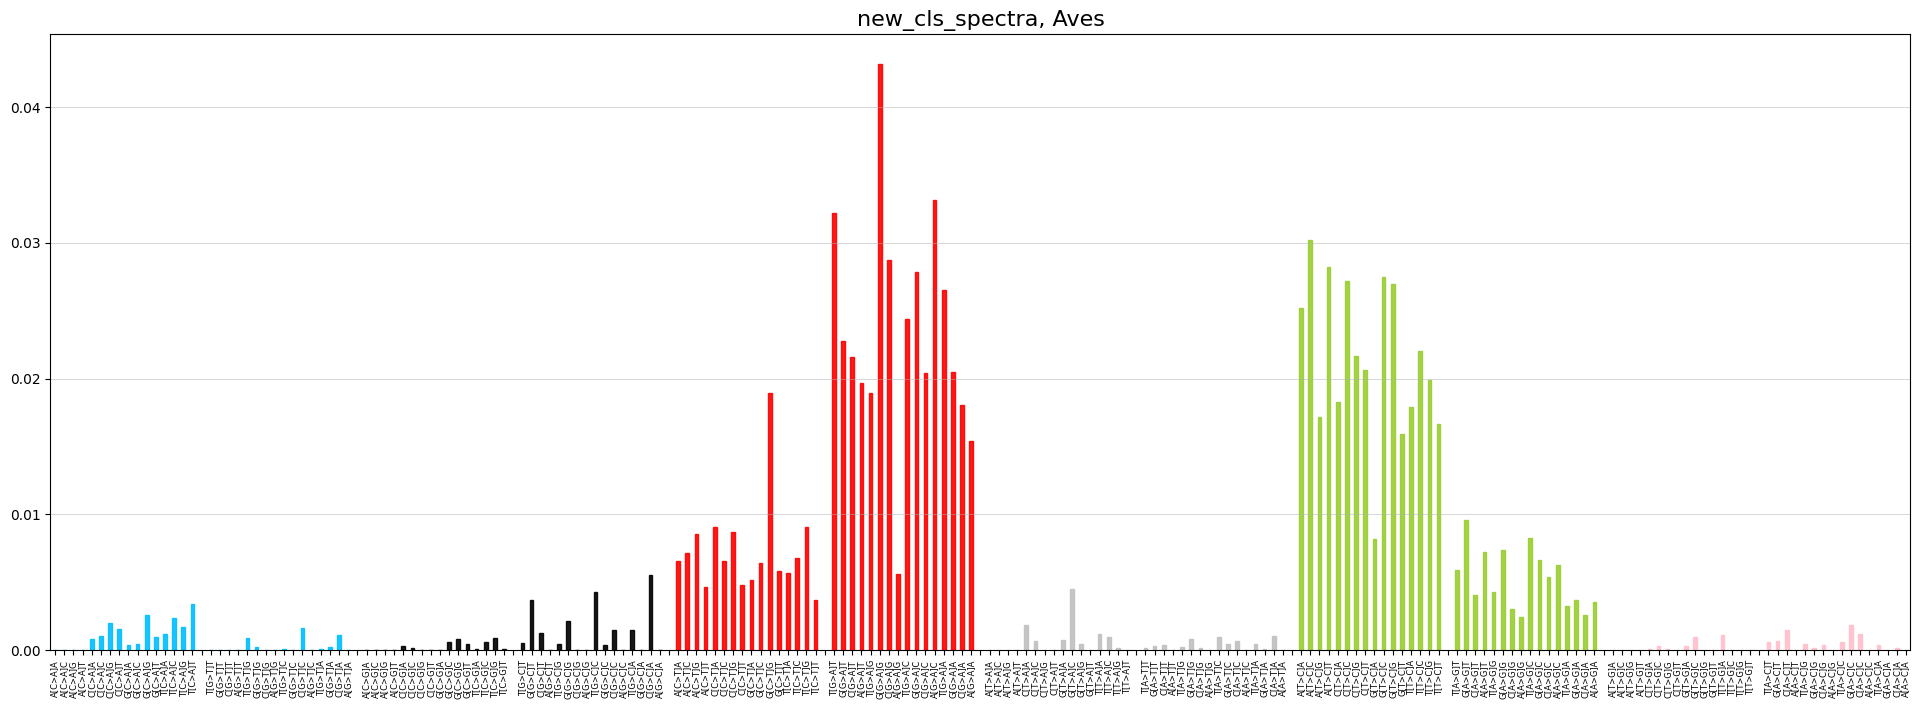

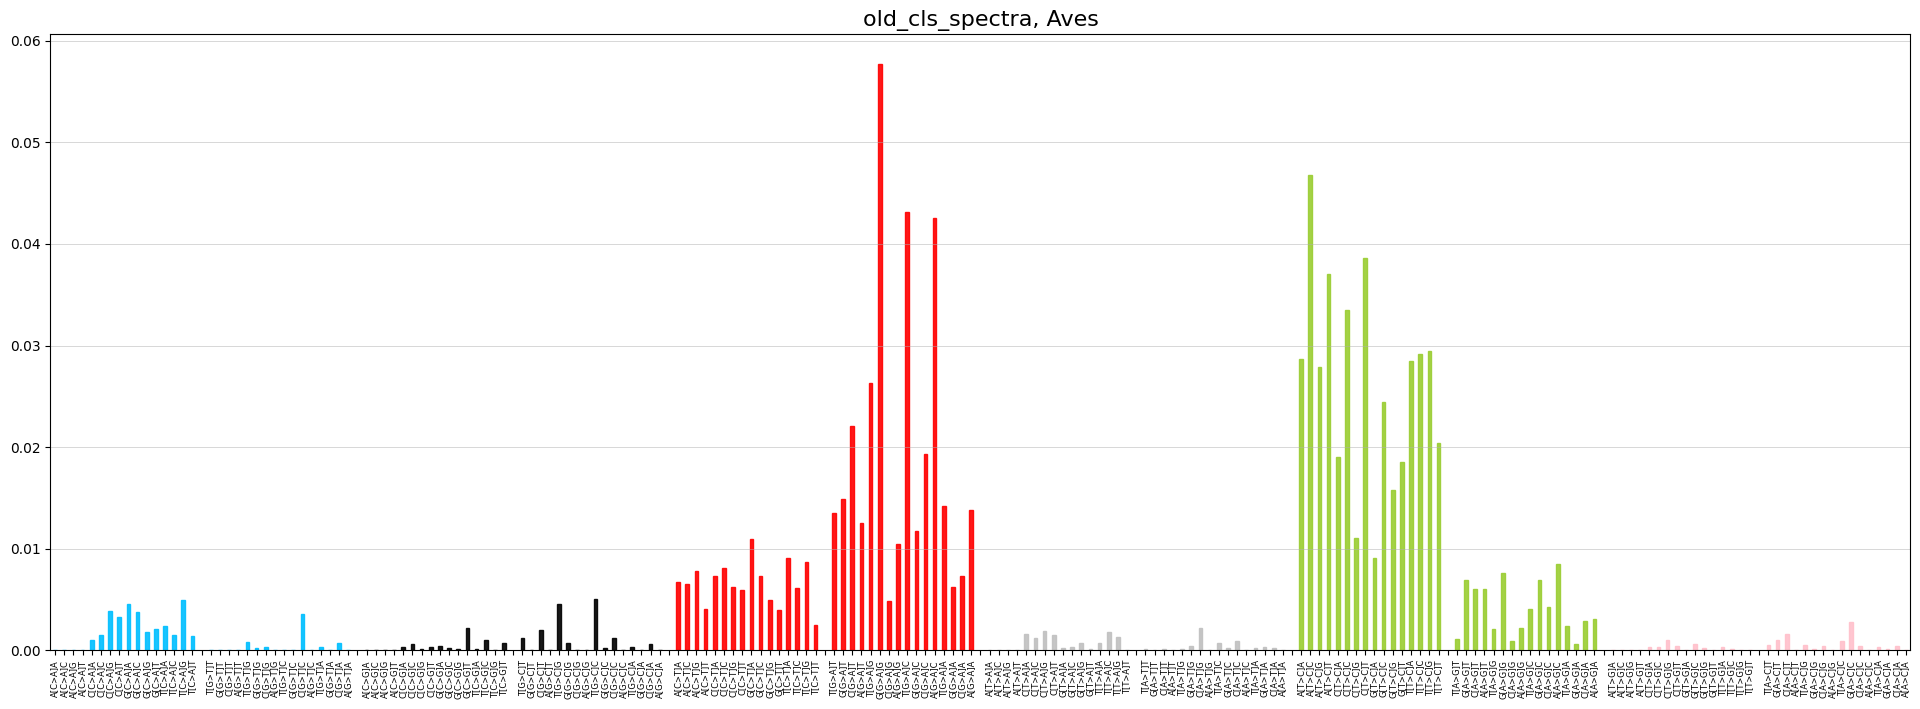

<AxesSubplot:title={'center':'old_cls_spectra, Aves'}>

In [61]:
plot_mutspec192(new_cls_spectra.loc['Aves'].rename('MutSpec').reset_index(), 
                title='new_cls_spectra, Aves')
plot_mutspec192(old_cls_spectra.loc['Aves'].rename('MutSpec').reset_index(), 
                title='old_cls_spectra, Aves')

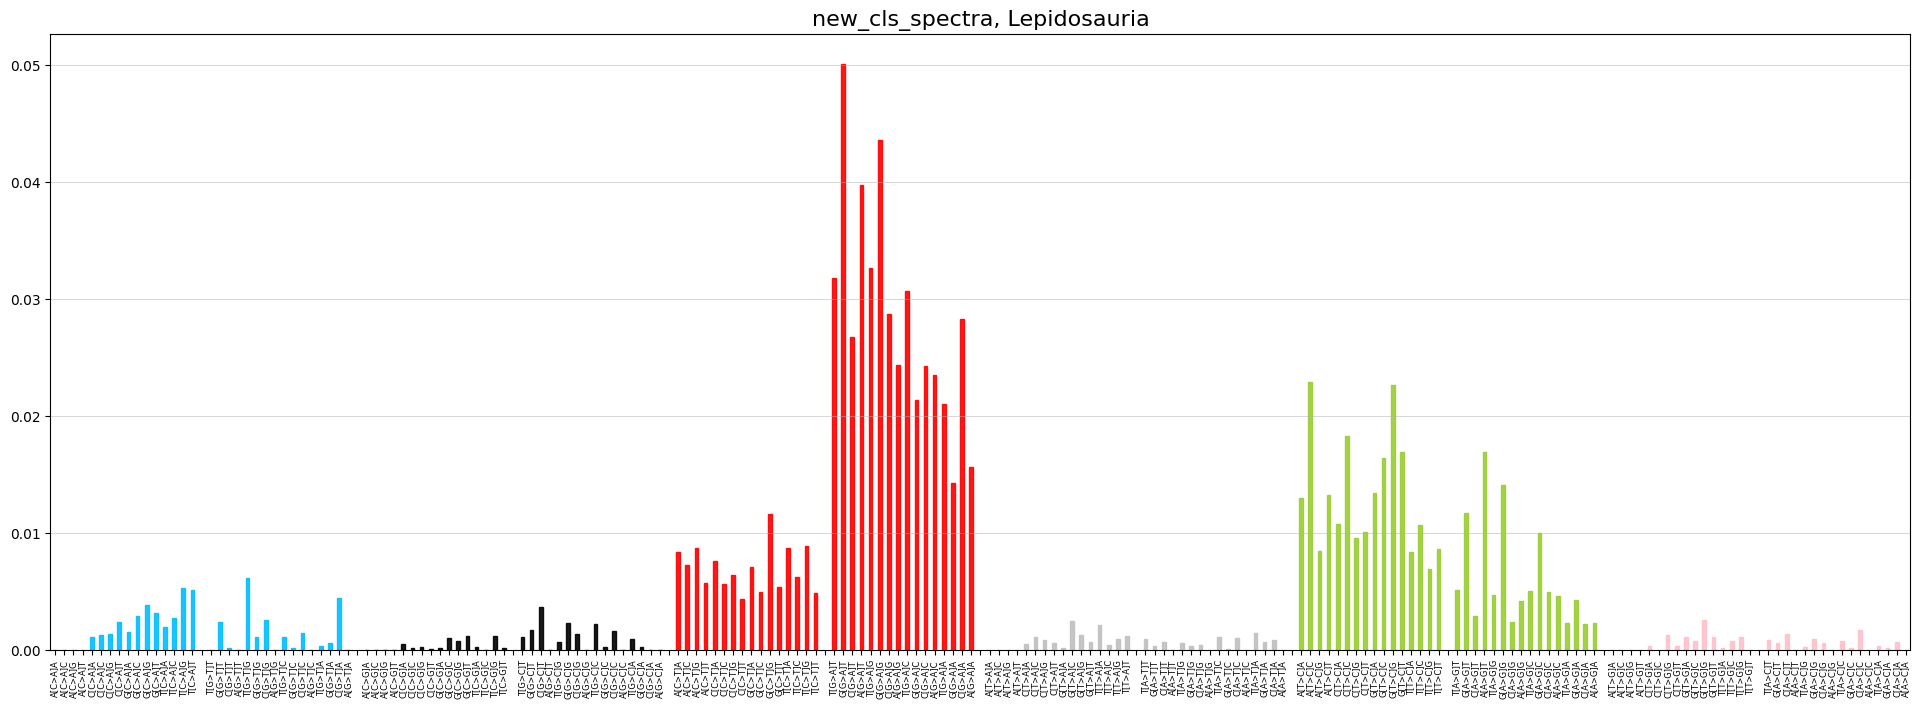

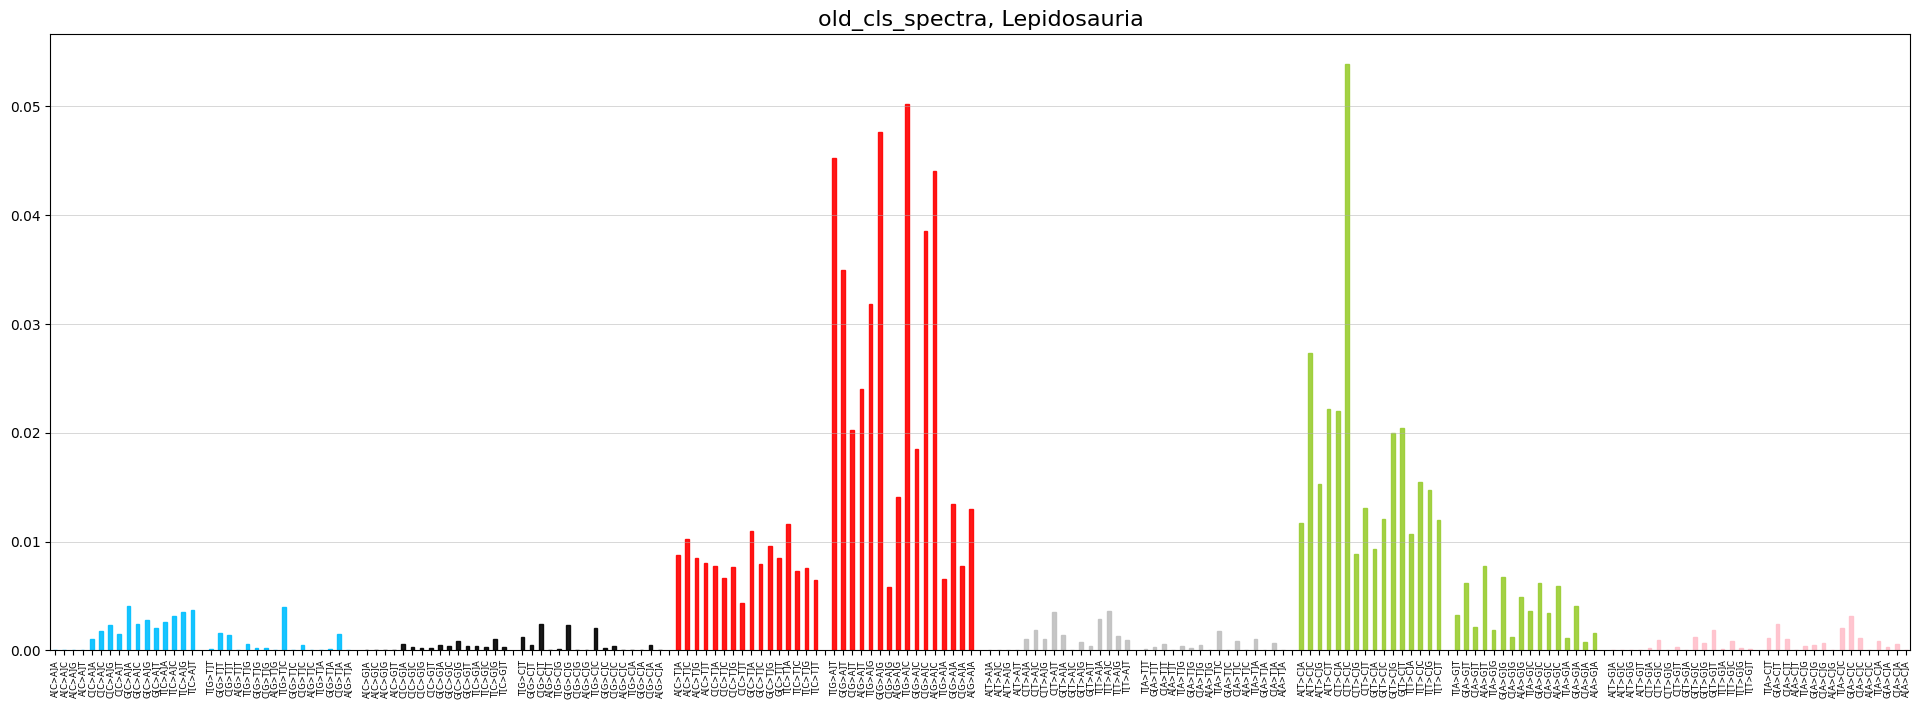

<AxesSubplot:title={'center':'old_cls_spectra, Lepidosauria'}>

In [62]:
plot_mutspec192(new_cls_spectra.loc['Lepidosauria'].rename('MutSpec').reset_index(), 
                title='new_cls_spectra, Lepidosauria')
plot_mutspec192(old_cls_spectra.loc['Lepidosauria'].rename('MutSpec').reset_index(), 
                title='old_cls_spectra, Lepidosauria')

### Species specific spectra

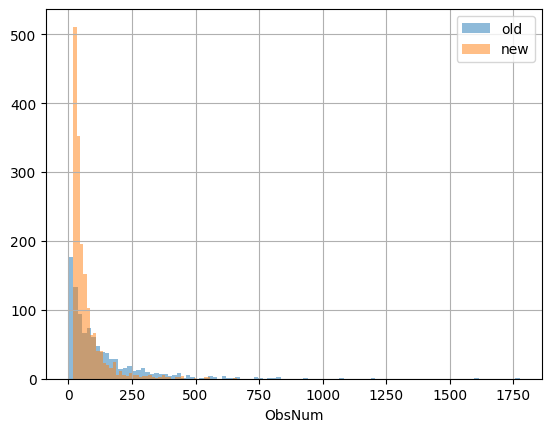

In [ ]:
old_dataset.groupby('Species').Observed.sum().hist(bins=100, label='old', alpha=0.5)
new_dataset.groupby('Species').Observed.sum().hist(bins=50, label='new', alpha=0.5)
plt.xlabel('ObsNum')
plt.legend()
plt.show()

In [129]:
new_species_spectra = new_dataset.set_index(['Class', 'Species', 'Mut'])\
    .MutSpec.unstack()
old_species_spectra = old_dataset.set_index(['Class', 'Species', 'Mut'])\
    .MutSpec.unstack()

new_species_obs = new_dataset.set_index(['Class', 'Species', 'Mut'])\
    .Observed.unstack()
old_species_obs = old_dataset.set_index(['Class', 'Species', 'Mut'])\
    .Observed.unstack()

new_species_exp = new_dataset.set_index(['Class', 'Species', 'Mut'])\
    .Expected.unstack().fillna(0.)
old_species_exp = old_dataset.set_index(['Class', 'Species', 'Mut'])\
    .Expected.unstack()

In [130]:
common_species = old_species_spectra.index.intersection(new_species_spectra.index)
common_species.shape

(442,)

In [131]:
# Need to compare also only values of sbs, that was observed in old dataset.
# old dataset has more zeroes, therefore when calculating cossim, 
# huge difference raised from zeroes, that are not zeroes in the new dataset

new_species_spectra_masked = new_species_spectra.loc[common_species]\
    .mask(old_species_spectra.loc[common_species] == 0, 0.)
assert ((new_species_spectra_masked >= 0) == \
        (old_species_spectra.loc[common_species] >= 0)).all().all()

In [132]:
old_vs_new_species_sim = pd.concat([
    get_cossim(new_species_spectra, old_species_spectra).rename('Spectra'),
    get_cossim(new_species_spectra_masked, old_species_spectra).rename('Spectra-masked'),
    get_cossim(new_species_obs, old_species_obs).rename('Observed'),
    get_cossim(new_species_exp, old_species_exp).rename('Expected'),
], axis=1)
old_vs_new_species_sim.to_csv('./data/old_vs_new_species_sim.csv')
old_vs_new_species_sim

Spectra  Spectra-masked  Observed  \
Class       Species                                                          
Actinopteri Abbottina_rivularis         0.336930        0.697864  0.553447   
            Acanthopagrus_latus         0.094940        0.878043  0.239832   
            Acheilognathus_macropterus  0.367009        0.367009  0.626064   
            Acheilognathus_rhombeus     0.455733        0.458586  0.609401   
            Acipenser_gueldenstaedtii   0.699744        0.699744  0.850992   
...                                          ...             ...       ...   
Mammalia    Uropsilus_soricipes         0.647522        0.673930  0.624718   
            Ursus_arctos                0.189856        0.643890  0.891669   
            Ursus_thibetanus            0.364800        0.686901  0.823159   
            Vulpes_lagopus              0.524429        0.524429  0.708944   
            Vulpes_vulpes               0.481597        0.778332  0.903624   

                                        Expected  
Class       Species                               
Actinopteri Abbottina_rivularis         0.996178  
            Acanthopagrus_latus         0.999364  
            Acheilognathus_macropterus  0.996824  
            Acheilognathus_rhombeus     0.996315  
            Acipenser_gueldenstaedtii   0.997979  
...                                          ...  
Mammalia    Uropsilus_soricipes         0.998208  
            Ursus_arctos                0.994942  
            Ursus_thibetanus            0.998613  
            Vulpes_lagopus              0.999164  
            Vulpes_vulpes               0.998379  

[442 rows x 4 columns]

In [133]:
# 441 for masked new spectra due to absence of intersected sbs with old spectra
old_vs_new_species_sim.describe().T

,count,mean,std,min,25%,50%,75%,max
Spectra,442.0,0.502382,0.218760,0.000000,0.338957,0.515799,0.676474,0.936970
Spectra-masked,441.0,0.675800,0.167044,0.164571,0.564929,0.693401,0.806468,0.993707
Observed,442.0,0.743007,0.145298,0.000000,0.667648,0.770233,0.850923,0.964129
Expected,442.0,0.993990,0.018687,0.640772,0.994243,0.997548,0.998798,0.999882


In [134]:
old_vs_new_species_sim.median(level=0)

,Spectra,Spectra-masked,Observed,Expected
Class,,,,
Actinopteri,0.515524,0.682254,0.757283,0.997856
Amphibia,0.486145,0.720091,0.745800,0.995353
Aves,0.520705,0.682407,0.725177,0.998005
Lepidosauria,0.425671,0.644450,0.709393,0.992870
Mammalia,0.523554,0.710043,0.791042,0.997500


In [162]:
#12
old_vs_new_species_sim12 = pd.concat([
    get_cossim(collapse_sbs192(new_species_spectra[possible_sbs192]),
               collapse_sbs192(old_species_spectra[possible_sbs192])).rename('Spectra'),
    get_cossim(collapse_sbs192(new_species_spectra_masked[possible_sbs192]),
               collapse_sbs192(old_species_spectra[possible_sbs192])).rename('Spectra-masked'),
    get_cossim(collapse_sbs192(new_species_obs[possible_sbs192].fillna(0.)),
               collapse_sbs192(old_species_obs[possible_sbs192])).rename('Observed'),
    get_cossim(collapse_sbs192(new_species_exp[possible_sbs192]),
               collapse_sbs192(old_species_exp[possible_sbs192])).rename('Expected'),
], axis=1)
# old_vs_new_species_sim12.to_csv('./data/old_vs_new_species_sim12.csv')
old_vs_new_species_sim12

Spectra  Spectra-masked  Observed  \
Class       Species                                                          
Actinopteri Abbottina_rivularis         0.637298        0.910070  0.744007   
            Acanthopagrus_latus         0.506968        0.878043  0.711612   
            Acheilognathus_macropterus  0.900131        0.900131  0.922003   
            Acheilognathus_rhombeus     0.936270        0.942136  0.985985   
            Acipenser_gueldenstaedtii   0.741600        0.741600  0.882663   
...                                          ...             ...       ...   
Mammalia    Uropsilus_soricipes         0.830716        0.919248  0.832813   
            Ursus_arctos                0.980699        0.963059  0.980442   
            Ursus_thibetanus            0.823542        0.972842  0.985274   
            Vulpes_lagopus              0.910191        0.910191  0.943562   
            Vulpes_vulpes               0.947058        0.979179  0.978206   

                                        Expected  
Class       Species                               
Actinopteri Abbottina_rivularis         0.999801  
            Acanthopagrus_latus         0.999959  
            Acheilognathus_macropterus  0.999749  
            Acheilognathus_rhombeus     0.999682  
            Acipenser_gueldenstaedtii   0.999971  
...                                          ...  
Mammalia    Uropsilus_soricipes         0.999931  
            Ursus_arctos                0.999586  
            Ursus_thibetanus            0.999924  
            Vulpes_lagopus              0.999939  
            Vulpes_vulpes               0.999832  

[442 rows x 4 columns]

In [163]:
# 441 for masked new spectra due to absence of intersected sbs with old spectra
old_vs_new_species_sim12.describe().T

,count,mean,std,min,25%,50%,75%,max
Spectra,442.0,0.893382,0.126273,0.126220,0.854537,0.938923,0.976929,0.999614
Spectra-masked,441.0,0.920918,0.092959,0.400408,0.897811,0.956468,0.980471,0.999704
Observed,442.0,0.918575,0.080000,0.371527,0.892611,0.943172,0.971397,0.996959
Expected,442.0,0.999135,0.008463,0.824459,0.999611,0.999856,0.999939,0.999996


In [164]:
old_vs_new_species_sim12.median(level=0)

,Spectra,Spectra-masked,Observed,Expected
Class,,,,
Actinopteri,0.947267,0.950908,0.929015,0.999864
Amphibia,0.942447,0.946775,0.914954,0.999713
Aves,0.886390,0.943986,0.944838,0.999906
Lepidosauria,0.942066,0.954461,0.948884,0.999649
Mammalia,0.934100,0.957679,0.952516,0.999863
